## Load and Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_set = pd.read_csv("../data/training_set_VU_DM.csv")

In [4]:
train_set.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


# Part 3 - Eda

In [5]:
df = train_set.copy()

In [6]:
df.columns

Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate'

In [7]:
print(df.shape)
df.duplicated(subset = ["srch_id", "prop_id"]).sum()  # prop_id is always unique within one search

(4958347, 54)


np.int64(0)

## 3.1 Adding Date Day

In [8]:
df.dtypes[:3]

srch_id       int64
date_time    object
site_id       int64
dtype: object

In [9]:
df["date_time"] = pd.to_datetime(df["date_time"])
date_col = df["date_time"].dt.floor("D")
df.insert(2, "date", date_col)
df.head()

,srch_id,date_time,date,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,893,3,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,10404,4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,21315,3,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,27348,2,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,29604,4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [10]:
df.dtypes[:3]

srch_id               int64
date_time    datetime64[ns]
date         datetime64[ns]
dtype: object

## 3.2 Handling Data Types

In [11]:
df.nunique().sort_values(ascending = False)

orig_destination_distance      530595
srch_id                        199795
srch_query_affinity_score      199387
date_time                      198615
prop_id                        129113
price_usd                       76465
gross_bookings_usd              60687
srch_destination_id             18127
prop_location_score2             9342
visitor_hist_adr_usd             7799
comp1_rate_percent_diff          1830
comp5_rate_percent_diff           645
comp2_rate_percent_diff           596
comp7_rate_percent_diff           585
comp3_rate_percent_diff           534
comp8_rate_percent_diff           491
comp4_rate_percent_diff           482
srch_booking_window               429
prop_log_historical_price         392
comp6_rate_percent_diff           380
prop_location_score1              337
visitor_hist_starrating           312
date                              242
visitor_location_country_id       210
prop_country_id                   172
position                           40
srch_length_

In [12]:
df.dtypes

srch_id                                 int64
date_time                      datetime64[ns]
date                           datetime64[ns]
site_id                                 int64
visitor_location_country_id             int64
visitor_hist_starrating               float64
visitor_hist_adr_usd                  float64
prop_country_id                         int64
prop_id                                 int64
prop_starrating                         int64
prop_review_score                     float64
prop_brand_bool                         int64
prop_location_score1                  float64
prop_location_score2                  float64
prop_log_historical_price             float64
position                                int64
price_usd                             float64
promotion_flag                          int64
srch_destination_id                     int64
srch_length_of_stay                     int64
srch_booking_window                     int64
srch_adults_count                 

In [13]:
cont_cols = ['visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_review_score', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'srch_query_affinity_score', 'orig_destination_distance', 'gross_bookings_usd', 'comp1_rate_percent_diff', 'comp2_rate_percent_diff', 'comp3_rate_percent_diff', 'comp4_rate_percent_diff', 'comp5_rate_percent_diff', 'comp6_rate_percent_diff', 'comp7_rate_percent_diff', 'comp8_rate_percent_diff']

bool_cols = ['prop_brand_bool', 'promotion_flag', 'srch_saturday_night_bool', 'random_bool', 'click_bool', 'booking_bool']

id_cols = ['srch_id', 'site_id', 'visitor_location_country_id', 'prop_country_id', 'prop_id', 'srch_destination_id']

cat_cols = ['comp1_rate', 'comp1_inv', 'comp2_rate', 'comp2_inv', 'comp3_rate', 'comp3_inv', 'comp4_rate', 'comp4_inv', 'comp5_rate', 'comp5_inv', 'comp6_rate', 'comp6_inv', 'comp7_rate', 'comp7_inv', 'comp8_rate', 'comp8_inv']

int_cols = ['prop_starrating', 'position', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count']

time_cols = ['date_time', 'date']

In [14]:
print(df.shape[1])
col_len = len(cont_cols) + len(bool_cols) + len(id_cols) + len(int_cols) + len(time_cols) + len(cat_cols)
print(col_len)

55
55


In [15]:
df[cont_cols] = df[cont_cols].astype('float32')
df[bool_cols] = df[bool_cols].astype('bool')
df[id_cols + cat_cols] = df[id_cols + cat_cols].astype('category')
df[int_cols] = df[int_cols].astype('int8')

In [16]:
df.dtypes

srch_id                              category
date_time                      datetime64[ns]
date                           datetime64[ns]
site_id                              category
visitor_location_country_id          category
visitor_hist_starrating               float32
visitor_hist_adr_usd                  float32
prop_country_id                      category
prop_id                              category
prop_starrating                      category
prop_review_score                     float32
prop_brand_bool                          bool
prop_location_score1                  float32
prop_location_score2                  float32
prop_log_historical_price             float32
position                                 int8
price_usd                             float32
promotion_flag                           bool
srch_destination_id                  category
srch_length_of_stay                      int8
srch_booking_window                      int8
srch_adults_count                 

## 3.3 Missing Values

In [17]:
df.nunique().sort_values(ascending = False)

orig_destination_distance      530595
srch_id                        199795
srch_query_affinity_score      199387
date_time                      198615
prop_id                        129113
price_usd                       76465
gross_bookings_usd              60687
srch_destination_id             18127
prop_location_score2             9342
visitor_hist_adr_usd             7799
comp1_rate_percent_diff          1830
comp5_rate_percent_diff           645
comp2_rate_percent_diff           596
comp7_rate_percent_diff           585
comp3_rate_percent_diff           534
comp8_rate_percent_diff           491
comp4_rate_percent_diff           482
prop_log_historical_price         392
comp6_rate_percent_diff           380
prop_location_score1              337
visitor_hist_starrating           312
srch_booking_window               256
date                              242
visitor_location_country_id       210
prop_country_id                   172
position                           40
srch_length_

In [18]:
miss_ratio = round(df.isna().sum().sort_values(ascending = False) / df.shape[0], 7)
miss_ratio

comp1_rate_percent_diff        0.980954
comp6_rate_percent_diff        0.980604
comp1_rate                     0.975812
comp1_inv                      0.973870
comp4_rate_percent_diff        0.973563
gross_bookings_usd             0.972090
comp7_rate_percent_diff        0.972064
comp6_rate                     0.951565
visitor_hist_starrating        0.949204
visitor_hist_adr_usd           0.948977
comp6_inv                      0.947366
comp4_rate                     0.938008
comp7_rate                     0.936401
srch_query_affinity_score      0.935986
comp4_inv                      0.930690
comp7_inv                      0.928117
comp3_rate_percent_diff        0.904646
comp2_rate_percent_diff        0.887818
comp8_rate_percent_diff        0.876021
comp5_rate_percent_diff        0.830367
comp3_rate                     0.690565
comp3_inv                      0.667028
comp8_rate                     0.613449
comp8_inv                      0.599160
comp2_rate                     0.591664


In [19]:
# Gross USD Availability
nr_bookings = df[df["booking_bool"] == 1].shape[0]

nr_gross_given_booking = df[
    (df["booking_bool"] == 1) & (df["gross_bookings_usd"].notna())
].shape[0]

ratio = nr_gross_given_booking / nr_bookings

print(f"Gross USD Availability Ratio (given booking): {ratio:.5f}")

Gross USD Availability Ratio (given booking): 1.00000


In [20]:
# Affinity Score: number of unique values
df.groupby("prop_id", observed = True)["srch_query_affinity_score"].nunique().sort_values(ascending = False)

prop_id
7377      81
41400     80
57125     78
106230    75
126657    74
          ..
140808     0
140806     0
140804     0
140802     0
20         0
Name: srch_query_affinity_score, Length: 129113, dtype: int64

In [21]:
# Overall booking rate
overall_booking_rate = df["booking_bool"].mean()

print("=== Overall Booking Rate ===")
print(f"Overall booking probability: {overall_booking_rate:.5f}\n")


# Competition 5: missing vs not missing
comp5_missing_rate = df[df["comp5_rate"].isna()]["booking_bool"].mean()
comp5_not_missing_rate = df[df["comp5_rate"].notna()]["booking_bool"].mean()

print("=== Competition 5 Availability ===")
print(f"Booking probability when comp5_rate is MISSING: {comp5_missing_rate:.5f}")
print(f"Booking probability when comp5_rate is AVAILABLE: {comp5_not_missing_rate:.5f}\n")


# All competition data missing
comp_rate_cols = [f"comp{i}_rate" for i in range(1, 9)]
all_missing = df[comp_rate_cols].isna().all(axis=1)

all_missing_ratio = all_missing.mean()
all_missing_booking_rate = df[all_missing]["booking_bool"].mean()

print("=== All Competitor Data Missing ===")
print(f"Proportion of rows where ALL competitor rates are missing: {all_missing_ratio:.5f}")
print(f"Booking probability when ALL competitor data is missing: {all_missing_booking_rate:.5f}\n")


# Any competitor cheaper
any_cheaper = (df[comp_rate_cols] == -1).any(axis=1)
booking_by_cheaper = df.groupby(any_cheaper)["booking_bool"].mean()

print("=== Effect of Cheaper Competitors ===")
print(f"Booking probability when NO competitor is cheaper: {booking_by_cheaper[False]:.5f}")
print(f"Booking probability when AT LEAST ONE competitor is cheaper: {booking_by_cheaper[True]:.5f}")

=== Overall Booking Rate ===
Overall booking probability: 0.02791

=== Competition 5 Availability ===
Booking probability when comp5_rate is MISSING: 0.02729
Booking probability when comp5_rate is AVAILABLE: 0.02868

=== All Competitor Data Missing ===
Proportion of rows where ALL competitor rates are missing: 0.34625
Booking probability when ALL competitor data is missing: 0.02560

=== Effect of Cheaper Competitors ===
Booking probability when NO competitor is cheaper: 0.02835
Booking probability when AT LEAST ONE competitor is cheaper: 0.02464


In [22]:
df[["comp1_rate", "comp2_rate", "comp3_rate", "comp4_rate", "comp5_rate", "comp6_rate", "comp7_rate", "comp8_rate"]].isna().corr()

,comp1_rate,comp2_rate,comp3_rate,comp4_rate,comp5_rate,comp6_rate,comp7_rate,comp8_rate
comp1_rate,1.000000,-0.067407,-0.039993,0.058655,0.161121,0.304240,0.307899,-0.038753
comp2_rate,-0.067407,1.000000,0.529442,0.120364,0.311129,-0.172108,-0.202210,0.529978
comp3_rate,-0.039993,0.529442,1.000000,0.130998,0.267302,-0.141990,-0.162491,0.596642
comp4_rate,0.058655,0.120364,0.130998,1.000000,0.196496,-0.040808,-0.052271,-0.078920
comp5_rate,0.161121,0.311129,0.267302,0.196496,1.000000,0.214468,0.241800,0.309371
comp6_rate,0.304240,-0.172108,-0.141990,-0.040808,0.214468,1.000000,0.655467,-0.161746
comp7_rate,0.307899,-0.202210,-0.162491,-0.052271,0.241800,0.655467,1.000000,-0.185109
comp8_rate,-0.038753,0.529978,0.596642,-0.078920,0.309371,-0.161746,-0.185109,1.000000


## 3.4 Feature Distributions

#### Category Features (not IDs)

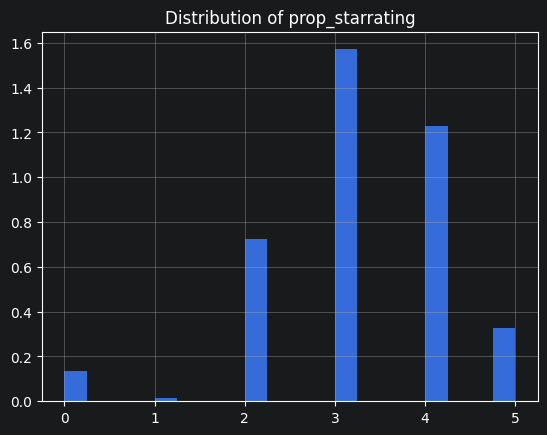

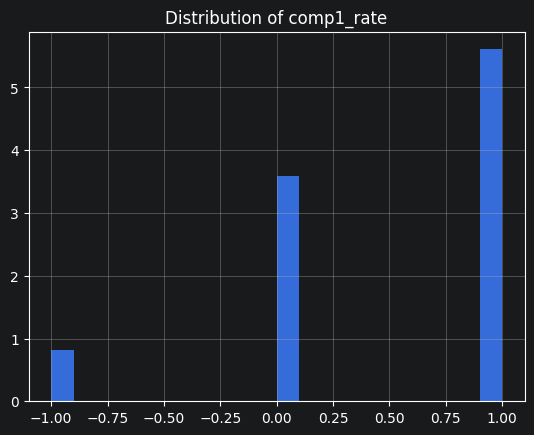

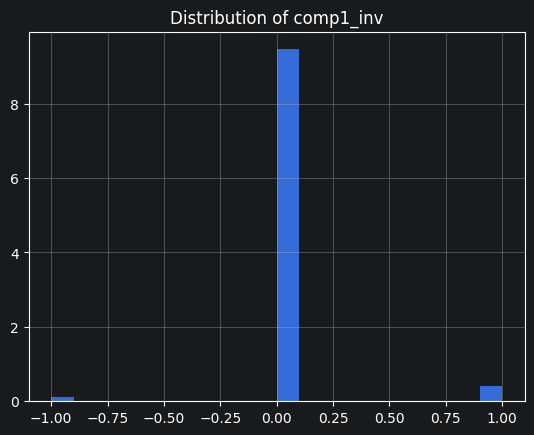

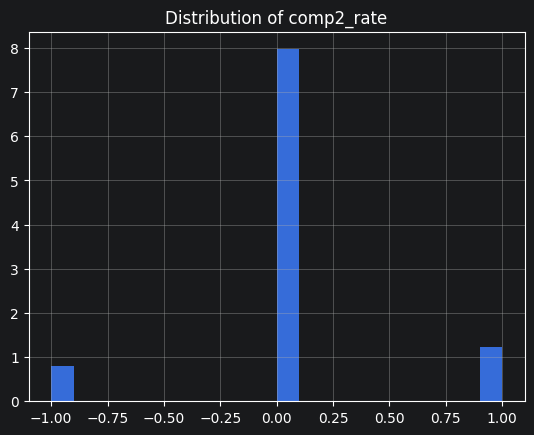

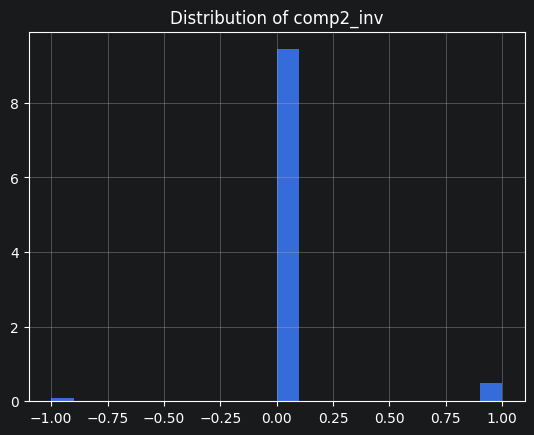

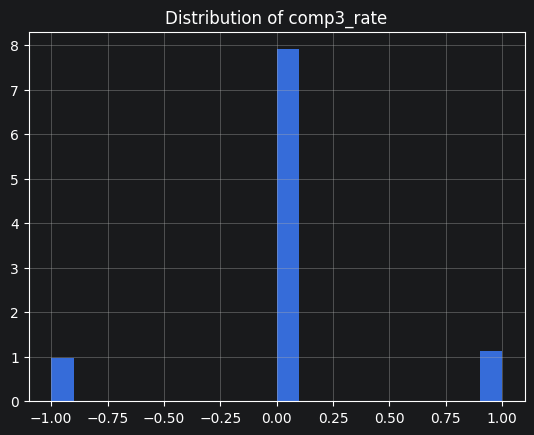

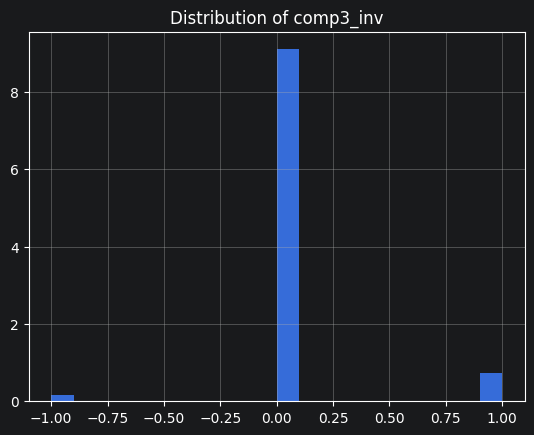

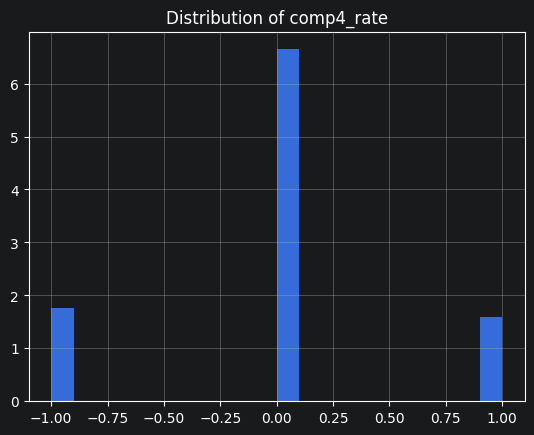

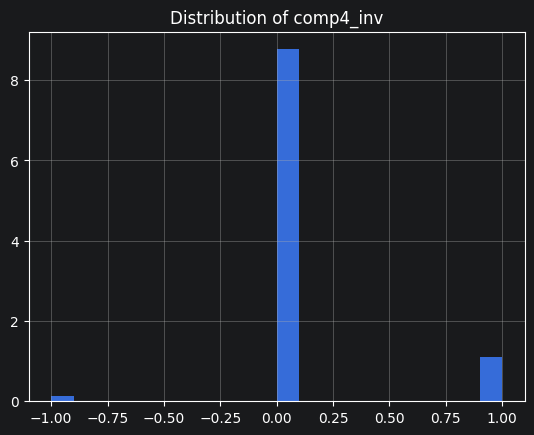

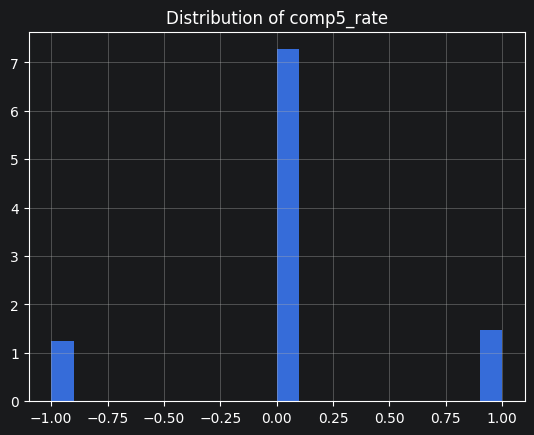

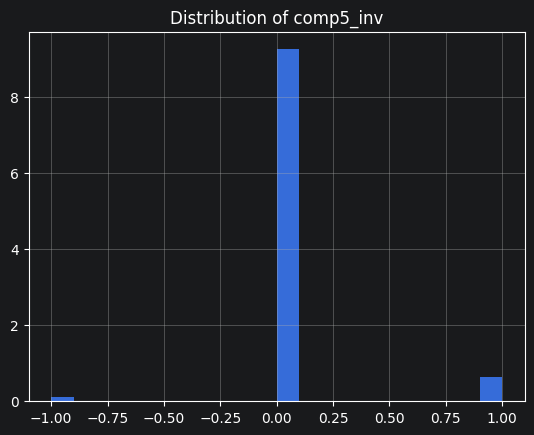

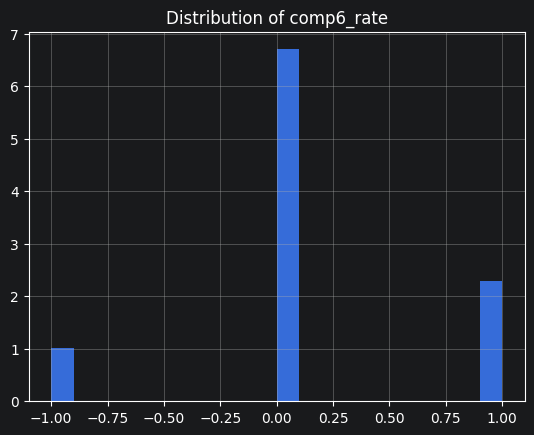

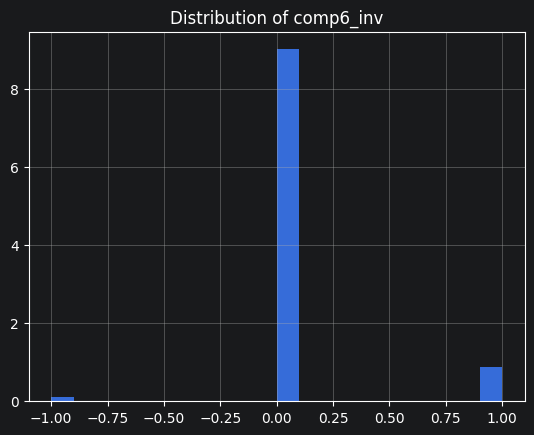

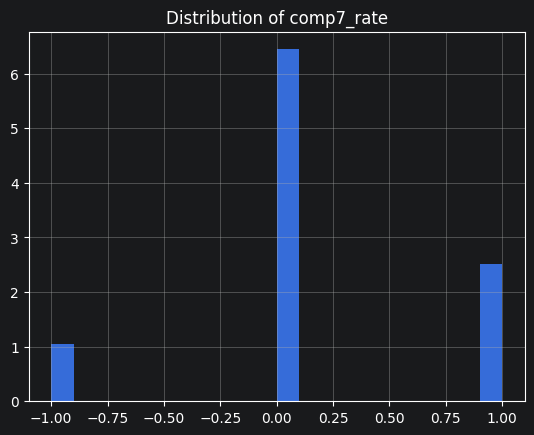

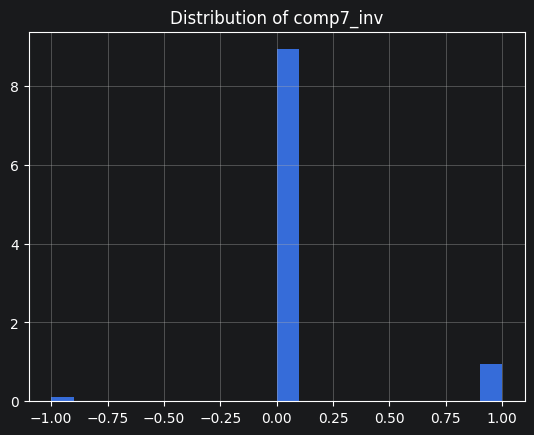

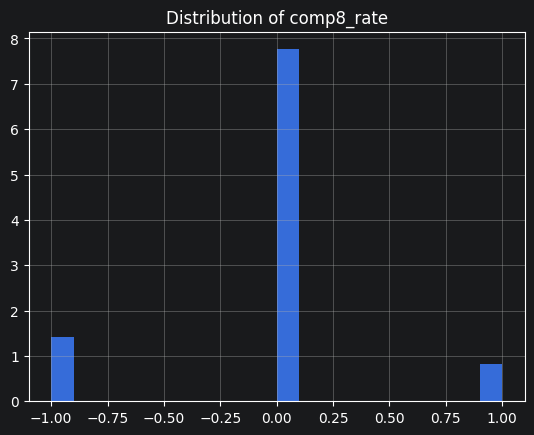

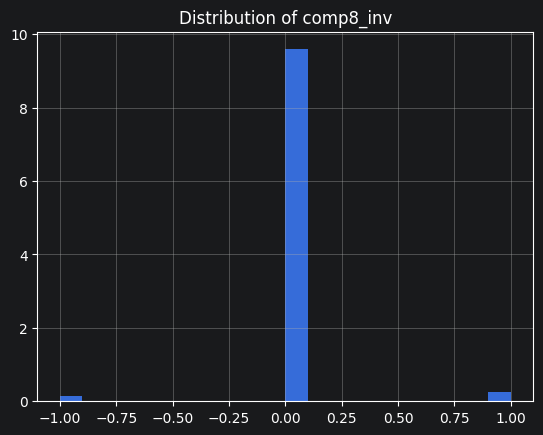

In [23]:
for col in cat_cols:
    plt.figure()
    df[col].hist(bins = 20, density = True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [24]:
df[(df["comp5_inv"] == -1) & (df["booking_bool"] == 1)].shape[0]

975

#### Continuous Features

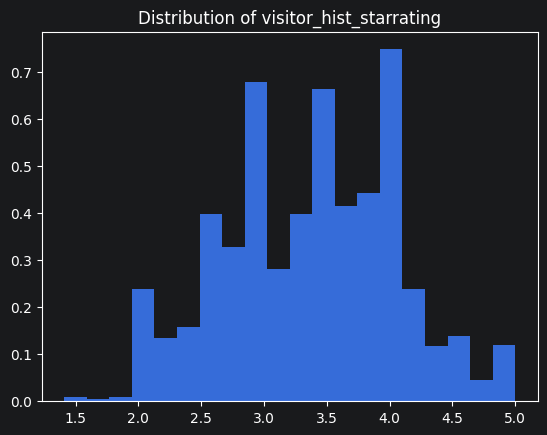

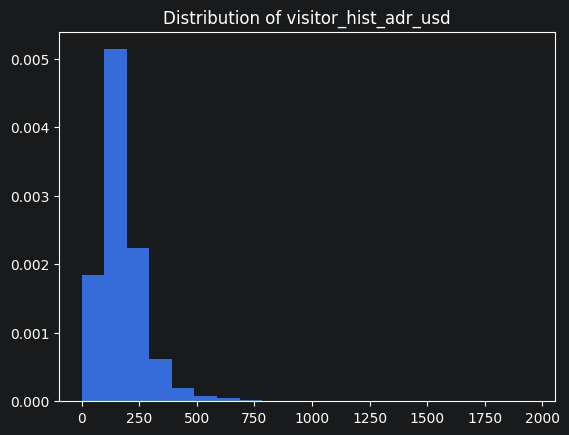

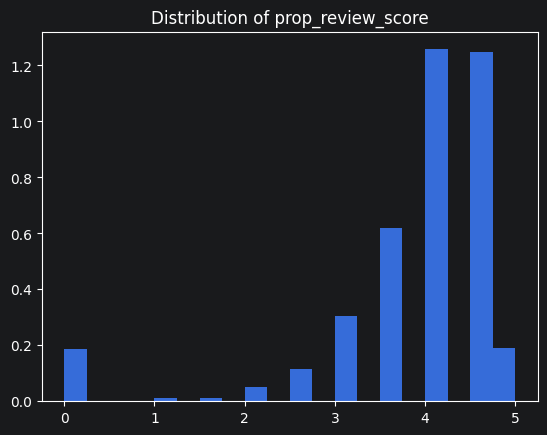

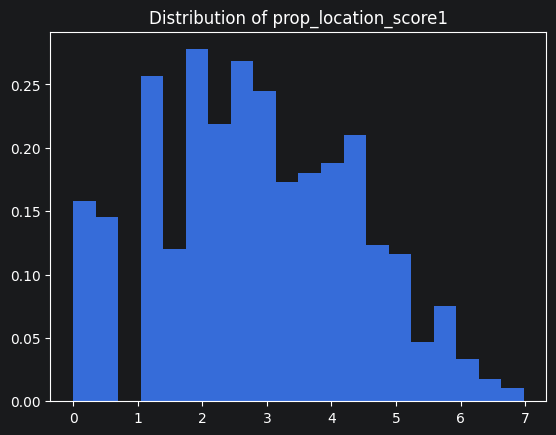

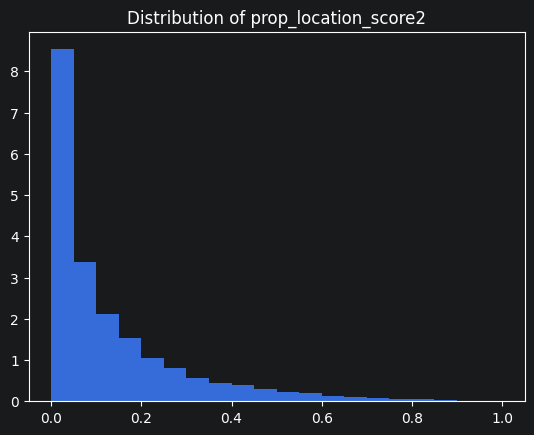

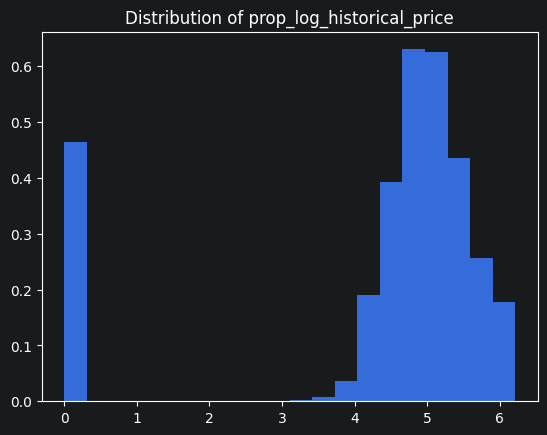

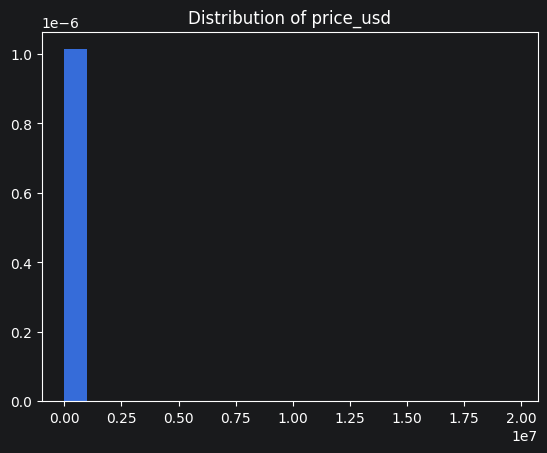

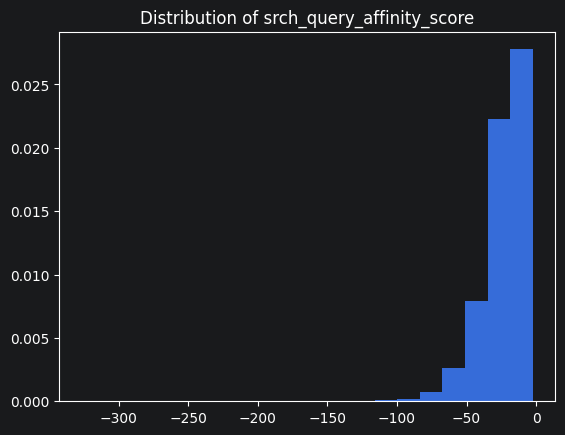

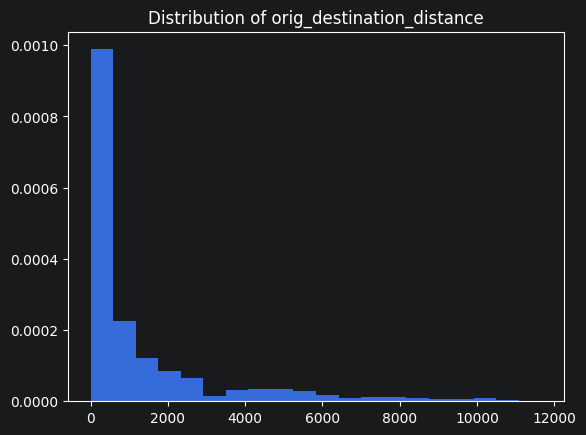

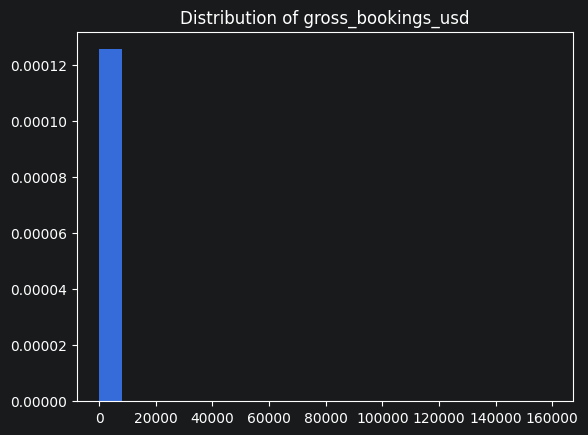

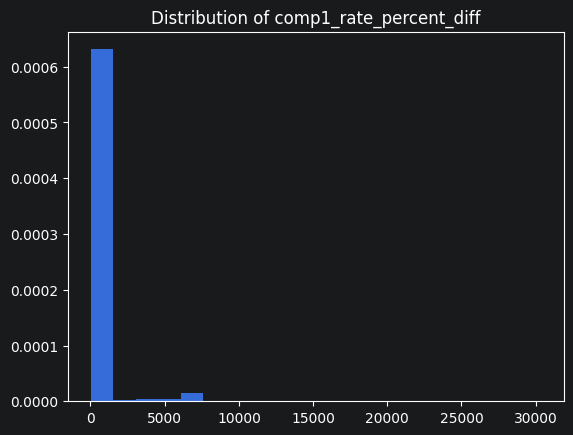

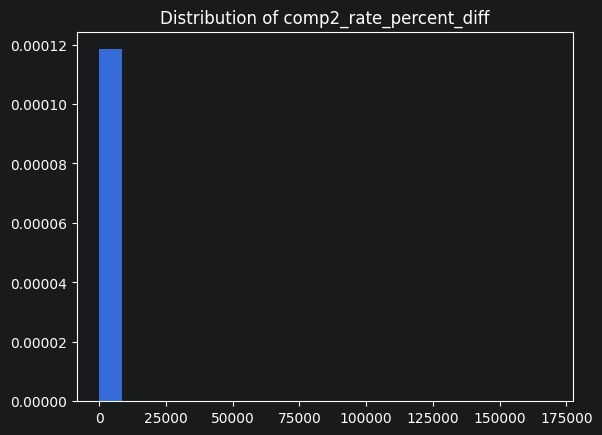

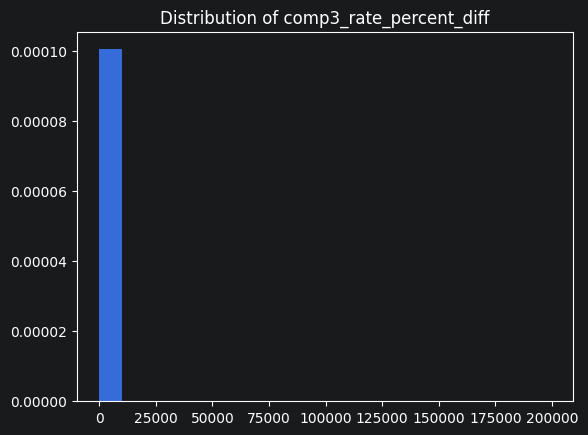

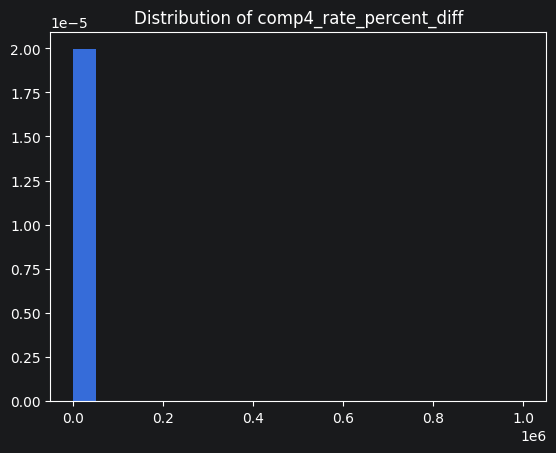

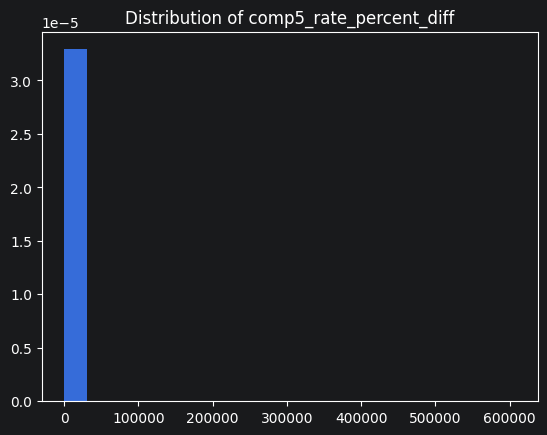

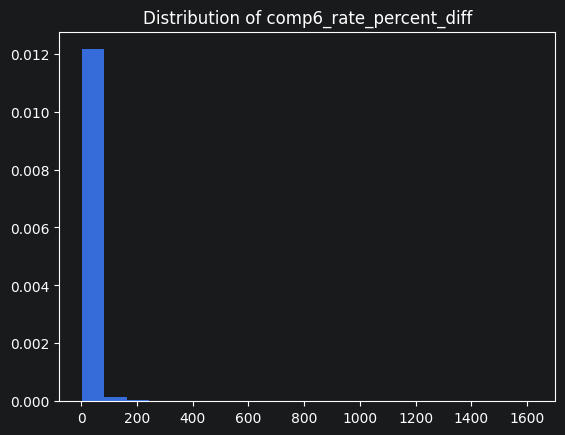

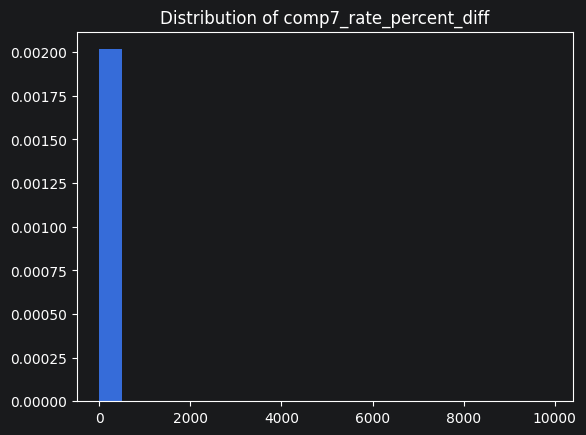

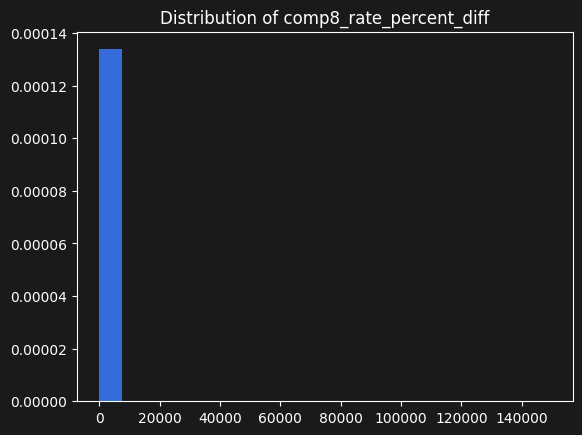

In [25]:
for col in cont_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins = 20, density = True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Int Cols

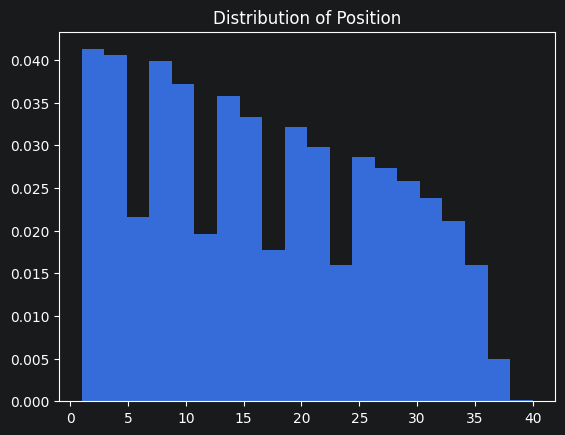

In [26]:
# Position
plt.figure()
plt.hist(df["position"], bins = 20, density = True)
plt.title(f"Distribution of Position")
plt.show()

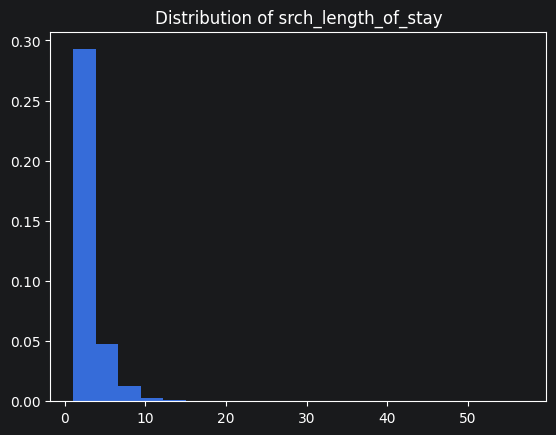

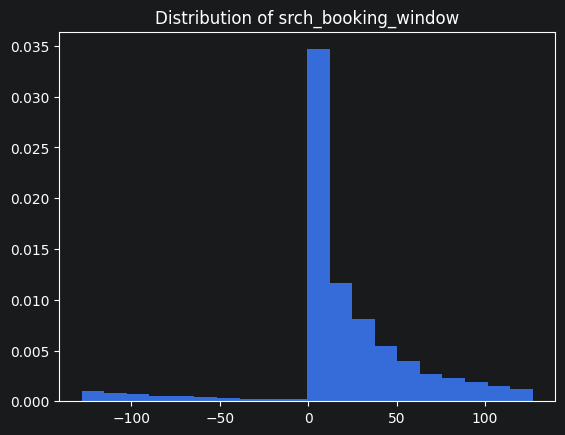

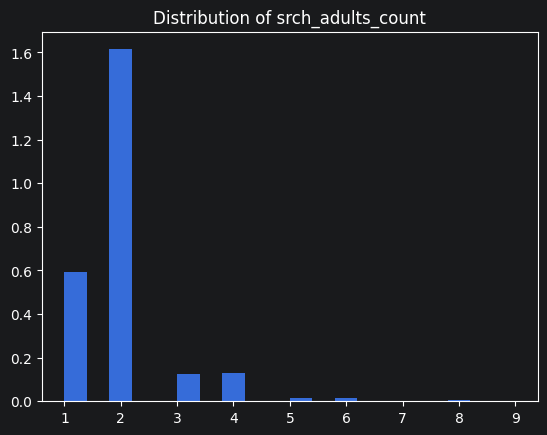

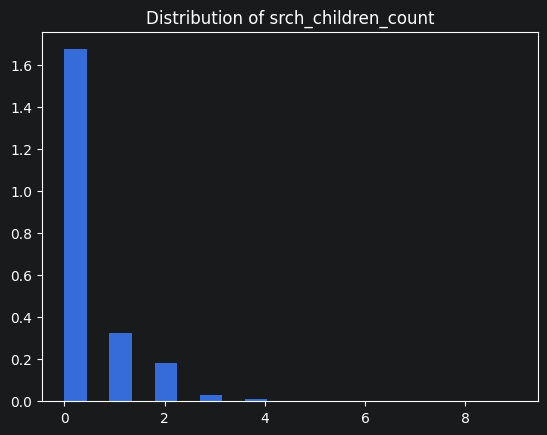

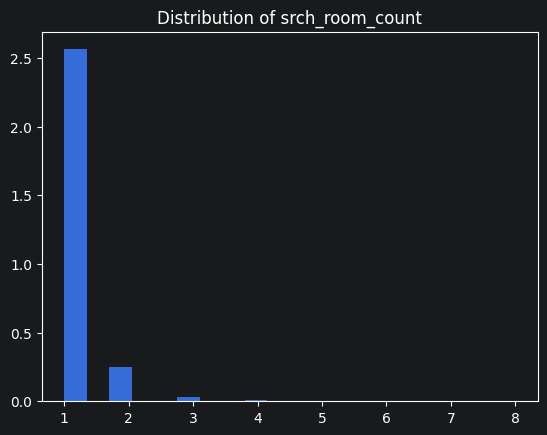

In [27]:
# Int cols
search_level_int_cols = [
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count"
]
for col in search_level_int_cols:
    plt.figure()
    plt.hist(df.groupby("srch_id", observed = True)[col].mean().dropna(), bins = 20, density = True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Boolean Features

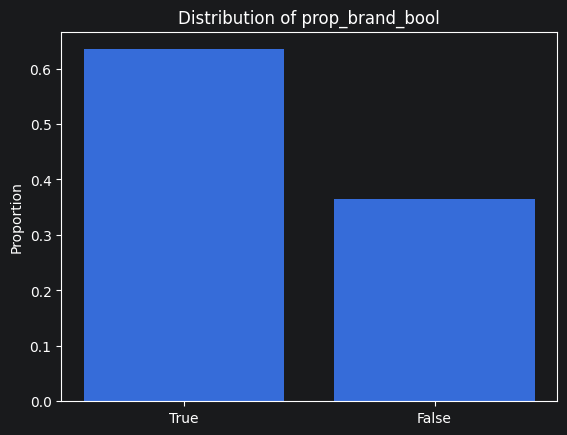

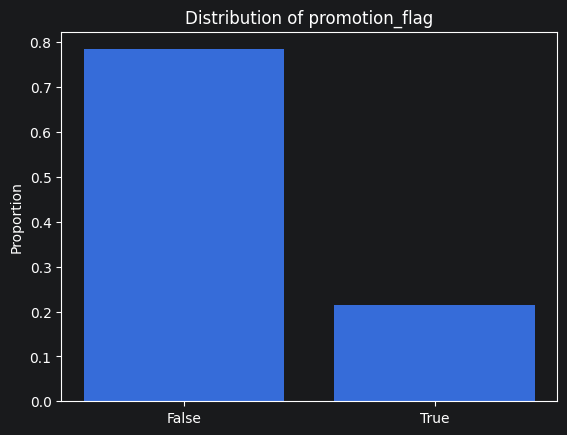

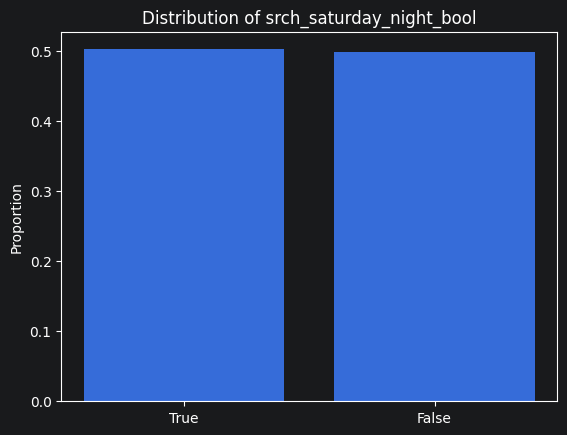

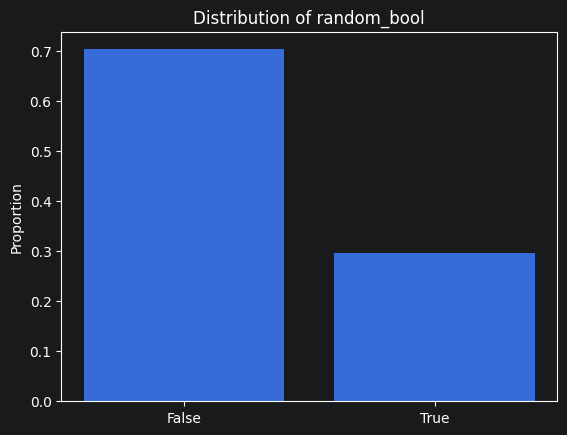

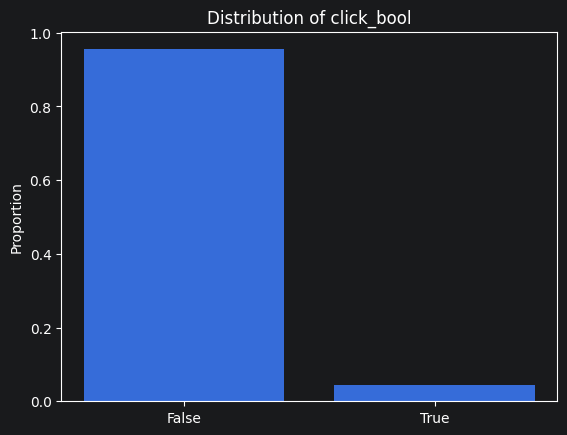

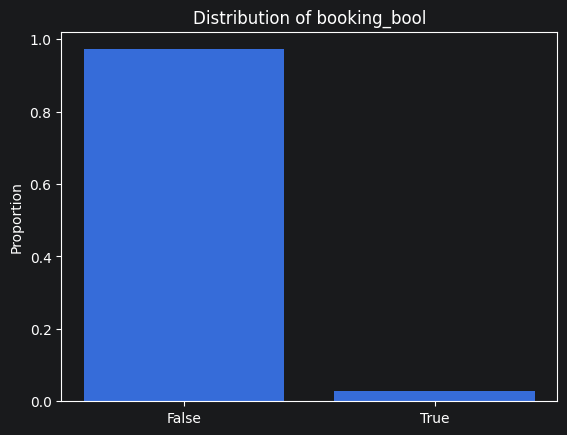

In [28]:
for col in bool_cols:

    counts = df[col].value_counts(normalize=True)

    plt.figure()

    plt.bar(
        counts.index.astype(str),
        counts.values
    )

    plt.title(f"Distribution of {col}")
    plt.ylabel("Proportion")

    plt.show()

## 3.5 Handling Outliers

In [29]:
df.describe()

,date_time,date,visitor_hist_starrating,visitor_hist_adr_usd,prop_review_score,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,...,orig_destination_distance,comp1_rate_percent_diff,comp2_rate_percent_diff,comp3_rate_percent_diff,comp4_rate_percent_diff,comp5_rate_percent_diff,comp6_rate_percent_diff,comp7_rate_percent_diff,comp8_rate_percent_diff,gross_bookings_usd
count,4958347,4958347,251866.000000,252988.000000,4.950983e+06,4.958347e+06,3.867999e+06,4.958347e+06,4.958347e+06,4.958347e+06,...,3.350565e+06,94439.000000,556238.000000,472797.000000,1.310860e+05,841099.000000,96174.000000,138515.000000,614730.000000,138390.000000
mean,2013-03-11 06:19:37.890842880,2013-03-10 16:07:33.460801024,3.374335,176.022583,3.777776e+00,2.872588e+00,1.303852e-01,4.317914e+00,1.685624e+01,2.542097e+02,...,1.301235e+03,244.229996,18.490732,27.071560,1.753166e+02,29.851929,17.250473,19.433268,22.430384,386.283295
min,2012-11-01 00:08:29,2012-11-01 00:00:00,1.410000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,...,1.000000e-02,2.000000,2.000000,2.000000,2.000000e+00,2.000000,2.000000,2.000000,2.000000,0.000000
25%,2013-01-14 17:47:32,2013-01-14 00:00:00,2.920000,109.809998,3.500000e+00,1.790000e+00,1.900000e-02,4.450000e+00,8.000000e+00,8.500000e+01,...,1.398000e+02,7.000000,7.000000,7.000000,7.000000e+00,7.000000,6.000000,7.000000,7.000000,124.000000
50%,2013-03-13 20:13:18,2013-03-13 00:00:00,3.450000,152.240005,4.000000e+00,2.770000e+00,6.900000e-02,4.910000e+00,1.600000e+01,1.220000e+02,...,3.866000e+02,10.000000,11.000000,11.000000,1.100000e+01,12.000000,11.000000,12.000000,11.000000,218.399994
75%,2013-05-10 00:01:38,2013-05-10 00:00:00,3.930000,213.490005,4.500000e+00,4.040000e+00,1.805000e-01,5.310000e+00,2.600000e+01,1.849600e+02,...,1.500670e+03,16.000000,20.000000,18.000000,1.900000e+01,21.000000,18.000000,20.000000,17.000000,429.790009
max,2013-06-30 23:58:24,2013-06-30 00:00:00,5.000000,1958.699951,5.000000e+00,6.980000e+00,1.000000e+00,6.210000e+00,4.000000e+01,1.972633e+07,...,1.166664e+04,30389.000000,168893.000000,199266.000000,1.001584e+06,607561.000000,1620.000000,9900.000000,149400.000000,159292.375000
std,NaN,NaN,0.692519,107.254494,1.050329e+00,1.531011e+00,1.594634e-01,1.834869e+00,1.042566e+01,1.600124e+04,...,2.023951e+03,1165.448608,240.113846,1012.919922,5.757740e+03,1340.262329,31.160313,54.370220,895.965881,821.190552


#### Price USD

In [30]:
price_995 = df["price_usd"].quantile(q = 0.995)
price_995

np.float64(770.0)

In [31]:
df["price_usd"] = df["price_usd"].clip(upper = price_995)

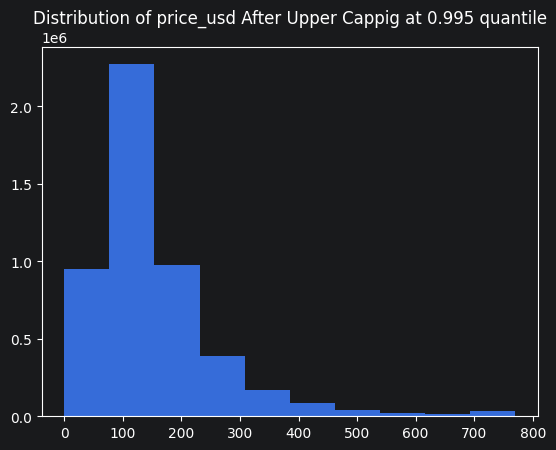

In [61]:
plt.figure()
plt.hist(df["price_usd"])
plt.title("Distribution of price_usd After Upper Cappig at 0.995 quantile")
plt.show()

#### Gross Bookings

In [33]:
gross_usd_995 = df["gross_bookings_usd"].quantile(q = 0.995)
gross_usd_995

np.float32(3315.477)

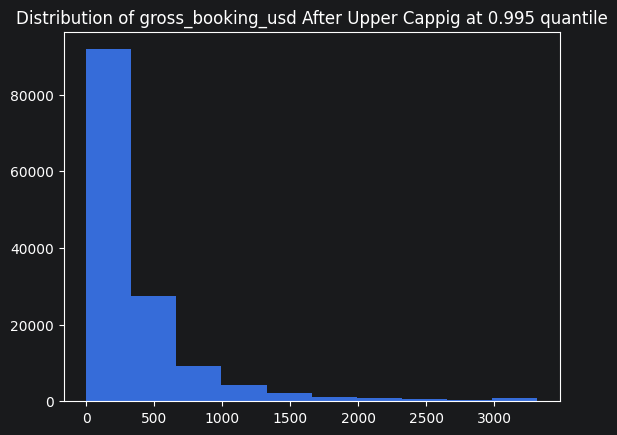

In [62]:
df["gross_bookings_usd"] = df["gross_bookings_usd"].clip(upper = gross_usd_995)
plt.figure()
plt.hist(df["gross_bookings_usd"])
plt.title("Distribution of gross_booking_usd After Upper Cappig at 0.995 quantile")
plt.show()

#### Competition Rate Diff

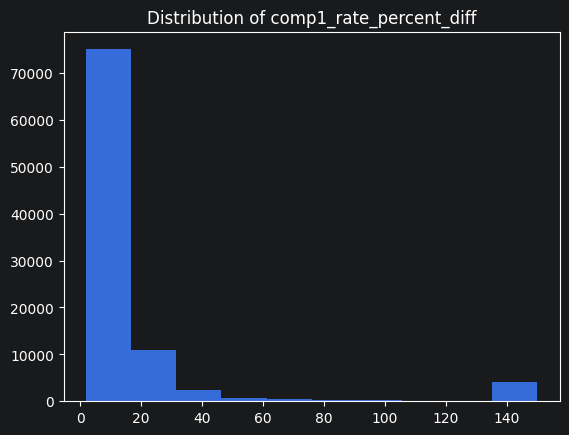

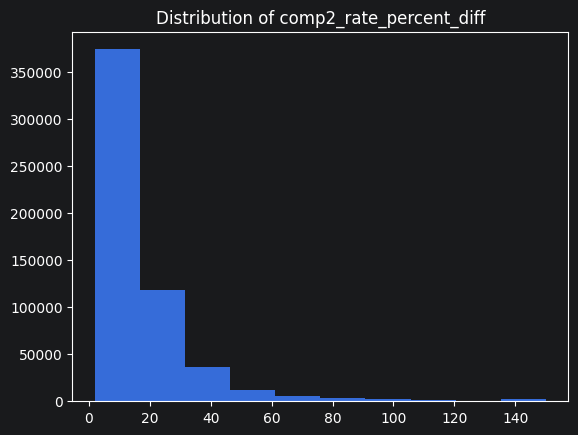

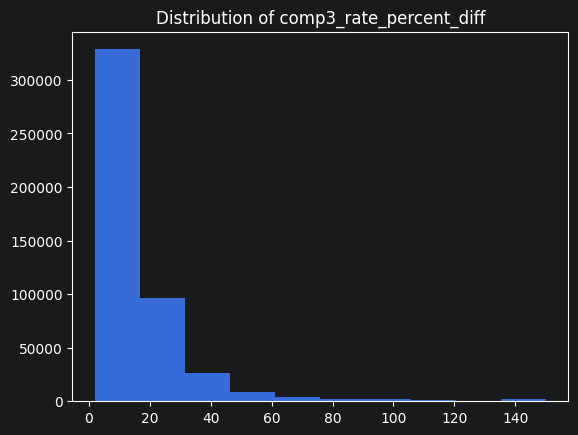

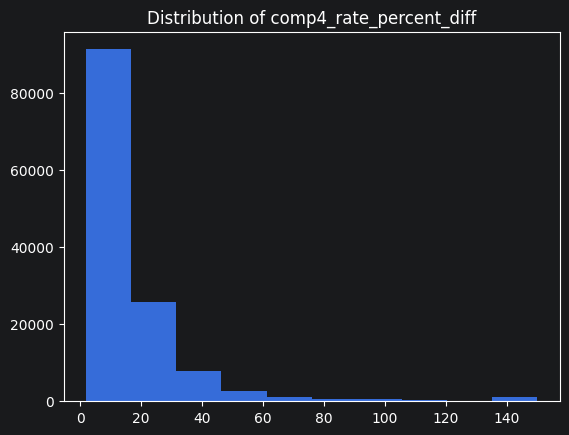

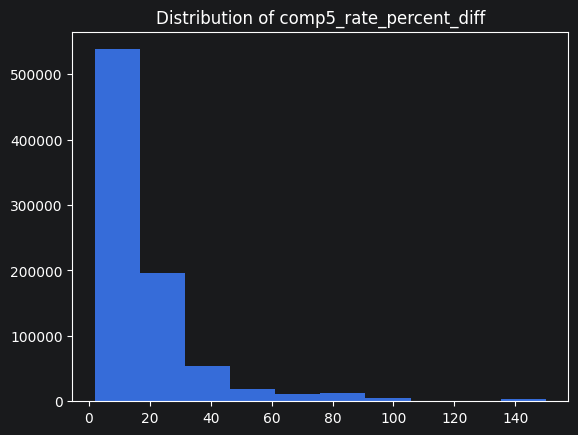

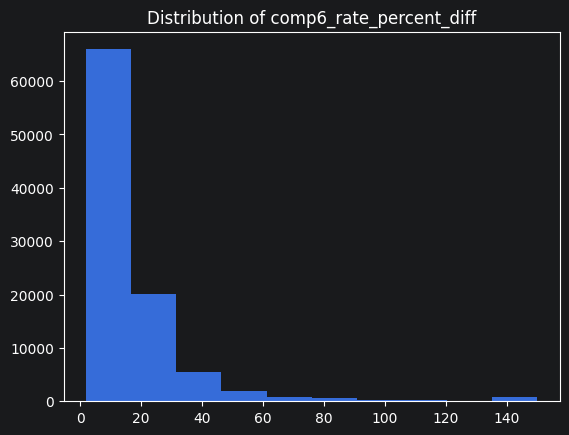

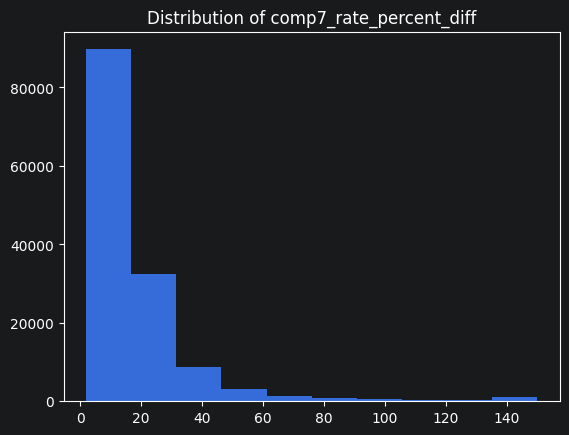

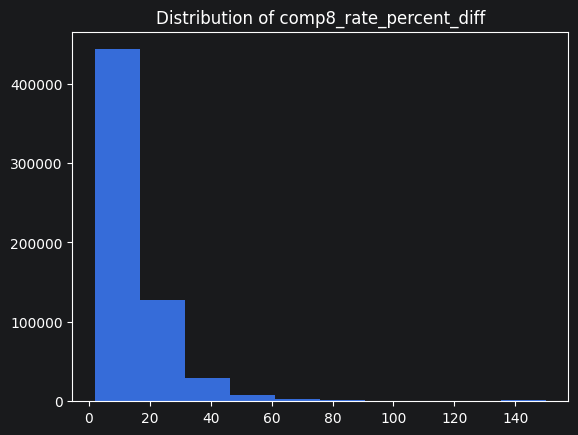

In [35]:
for i in range(1, 9):
    #upper995 = df[f"comp{i}_rate_percent_diff"].quantile(q = 0.995)
    df[f"comp{i}_rate_percent_diff"] = df[f"comp{i}_rate_percent_diff"].clip(upper = 150)
    plt.figure()
    plt.hist(df[f"comp{i}_rate_percent_diff"])
    plt.title(f"Distribution of comp{i}_rate_percent_diff")
    plt.show()


#### Search Booking Window

In [36]:
window_neg_ratio = df[df["srch_booking_window"] < 0].shape[0] / df.shape[0]
print(f"Ratio of faulty, negative values for booking window: {window_neg_ratio:.3f}")

Ratio of faulty, negative values for booking window: 0.063


In [37]:
# Create Negative Flag Feature for booking_window
df["booking_window_was_negative"] = (df["srch_booking_window"] < 0).astype("bool")

# Clip Values
df["srch_booking_window"] = df["srch_booking_window"].clip(lower = 0)

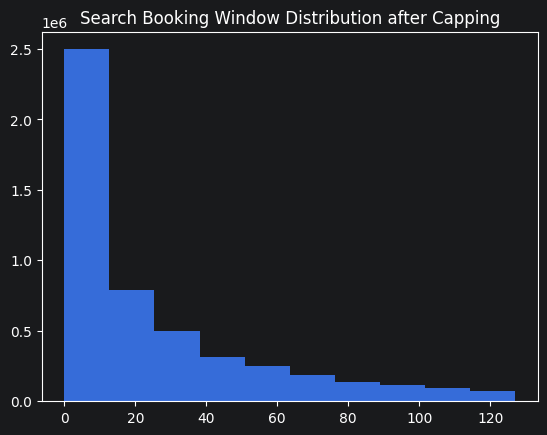

In [59]:
plt.figure()
plt.hist(df["srch_booking_window"])
plt.title("Search Booking Window Distribution after Capping")
plt.show()

## 3.6 Group By ID Base Stats

In [39]:
# Booking Ratio
booking_ratio = (df.groupby("srch_id", observed = True)["booking_bool"].mean() != 0).mean()
print(f"Ratio of booking in a search: {booking_ratio:.2f}")

Ratio of booking in a search: 0.69


In [40]:
# At least one click Ratio per Search
click_ratio = (df.groupby("srch_id", observed = True)["click_bool"].sum() != 0).mean()
average_n_clicks = (df.groupby("srch_id", observed = True)["click_bool"].sum()).mean()
print(f"Ratio of clicking at least one time in a search: {click_ratio:.2f}")
print(f"Average number of clicks per search: {average_n_clicks:.2f}")

Ratio of clicking at least one time in a search: 1.00
Average number of clicks per search: 1.11


## 3.7 Handling Time

In [41]:
# Creating Start of Stay Feature
df["start_of_stay"] = (df["date"] + pd.to_timedelta(df["srch_booking_window"], unit = "D"))

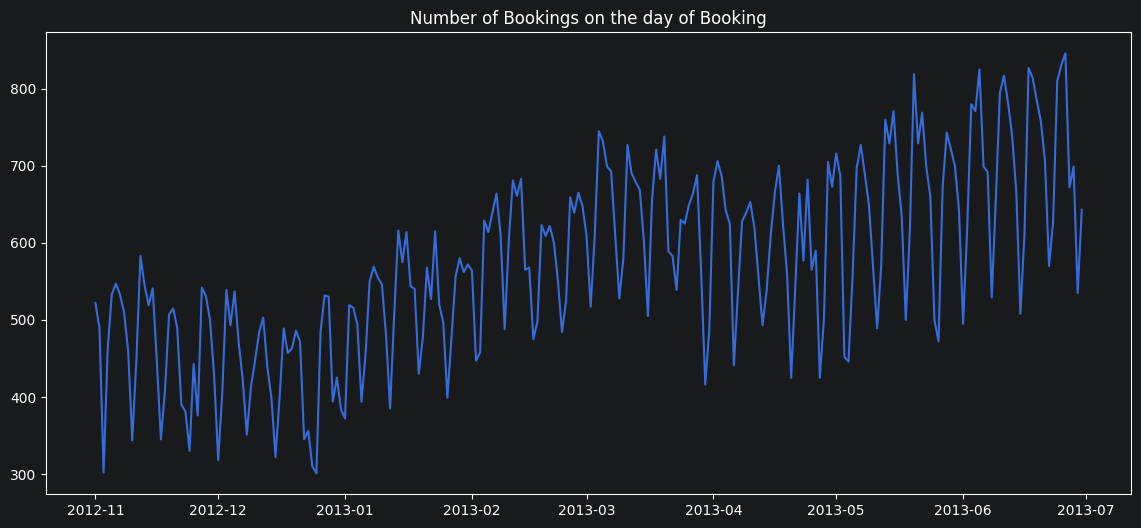

In [42]:
booking_days_sum = df.groupby("date")["booking_bool"].sum()
plt.figure(figsize = (14, 6))
plt.plot(booking_days_sum)
plt.title("Number of Bookings on the day of Booking")
plt.show()

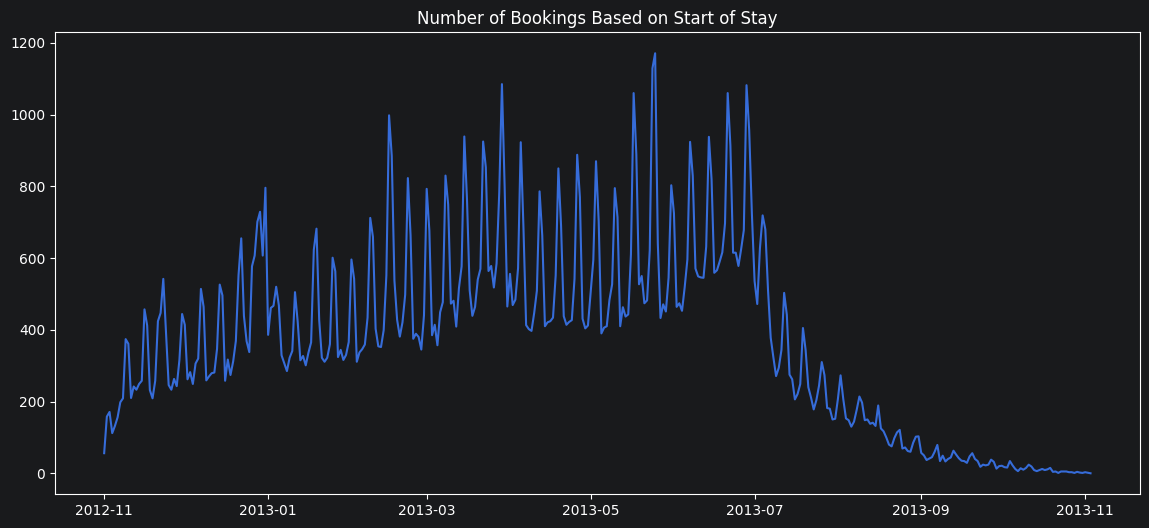

In [43]:
booking_start_sum = df.groupby("start_of_stay")["booking_bool"].sum()
plt.figure(figsize = (14, 6))
plt.plot(booking_start_sum)
plt.title("Number of Bookings Based on Start of Stay")
plt.show()

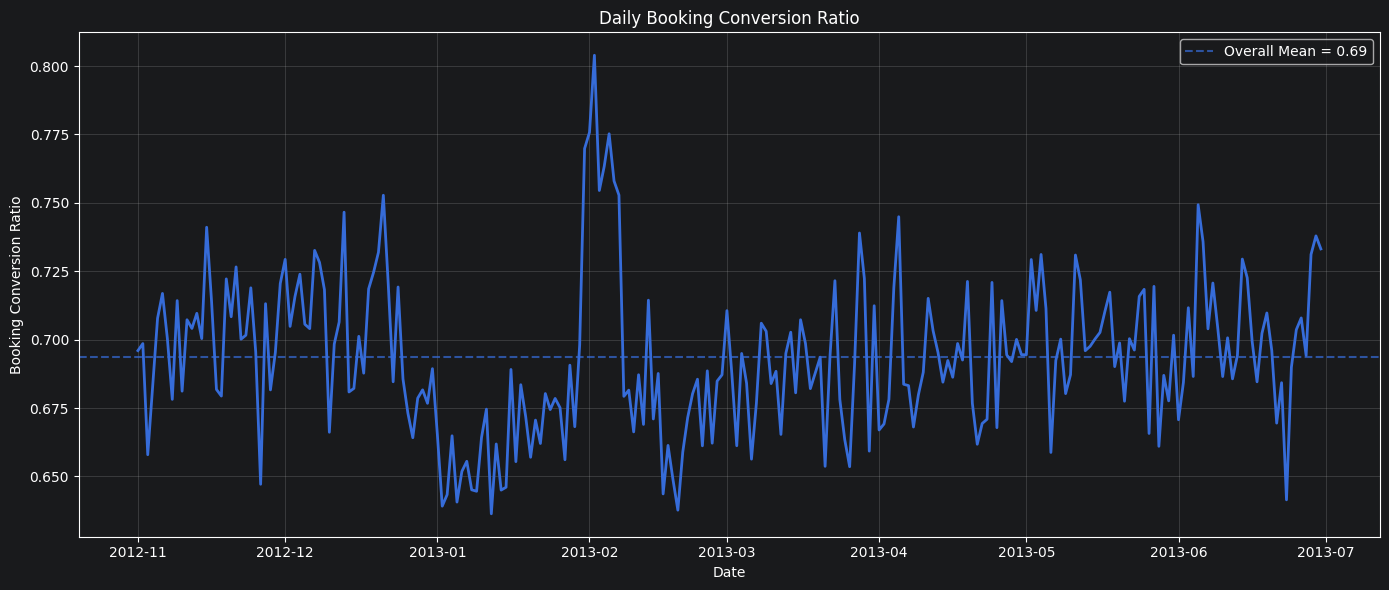

In [44]:
# ------------------------------------------
# Search-Level Daily Booking Conversion Rate
# ------------------------------------------

daily_booking_ratio = (
    df.groupby(["date", "srch_id"], observed=True)["booking_bool"]
      .max()                         # did this search end with a booking?
      .reset_index()
      .groupby("date")["booking_bool"]
      .mean()
)

# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    daily_booking_ratio.index,
    daily_booking_ratio.values,
    linewidth=2
)

# Overall booking conversion baseline
plt.axhline(
    y=daily_booking_ratio.mean(),
    linestyle="--",
    alpha=0.7,
    label=f"Overall Mean = {daily_booking_ratio.mean():.2f}"
)

plt.title("Daily Booking Conversion Ratio")
plt.xlabel("Date")
plt.ylabel("Booking Conversion Ratio")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Hourly Statistics
df["search_hour"] = df["date_time"].dt.hour
df["search_hour"] = df["search_hour"].astype("int8")
df["search_hour"].dtype

dtype('int8')

In [46]:
hourly_df = df.groupby("srch_id", observed=True).agg({
    "search_hour": "first",
    "booking_bool": "sum"
})


h_db = hourly_df.groupby("search_hour")["booking_bool"].mean()


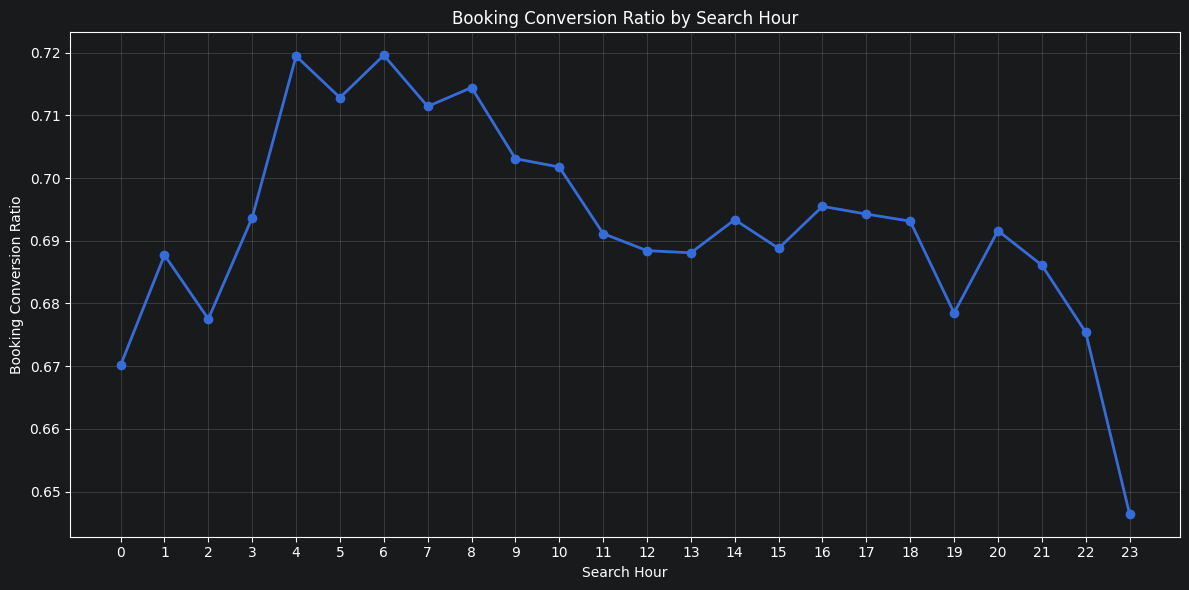

In [47]:
plt.figure(figsize=(12, 6))

plt.plot(
    h_db.index,
    h_db.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel("Search Hour")
plt.ylabel("Booking Conversion Ratio")
plt.title("Booking Conversion Ratio by Search Hour")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

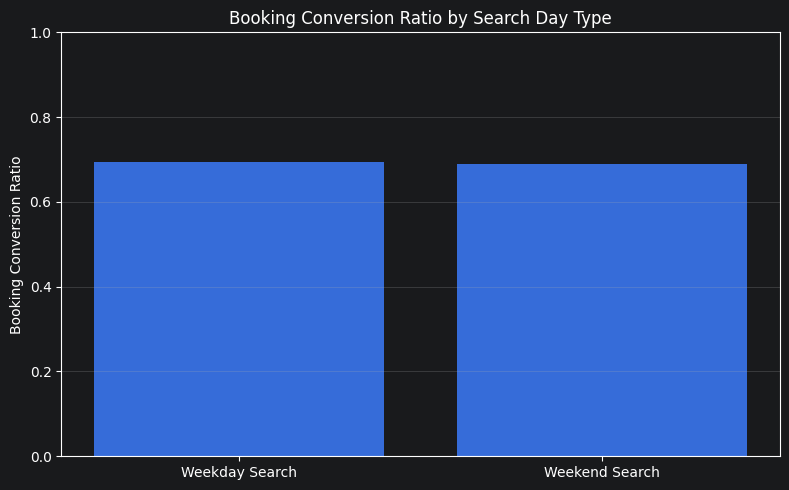

In [48]:
# Extract weekday
# Monday = 0, Sunday = 6
df["search_weekday"] = df["date_time"].dt.dayofweek

# Weekend search flag
df["is_weekend_search"] = (
    df["search_weekday"] >= 5
).astype("int8")


# ------------------------------------------
# Create Search-Level DataFrame
# ------------------------------------------

weekend_search_df = df.groupby("srch_id", observed=True).agg({
    "is_weekend_search": "mean",
    "booking_bool": "mean"
})

# Convert booking_bool into:
# Did this search end with a booking?
weekend_search_df["booking_bool"] = (
    weekend_search_df["booking_bool"] != 0
).astype("int8")


# ------------------------------------------
# Booking Conversion Ratio by Weekend Search
# ------------------------------------------

weekend_conversion = (
    weekend_search_df
    .groupby("is_weekend_search")["booking_bool"]
    .mean()
)


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["Weekday Search", "Weekend Search"],
    weekend_conversion.values
)

plt.ylabel("Booking Conversion Ratio")
plt.title("Booking Conversion Ratio by Search Day Type")

plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

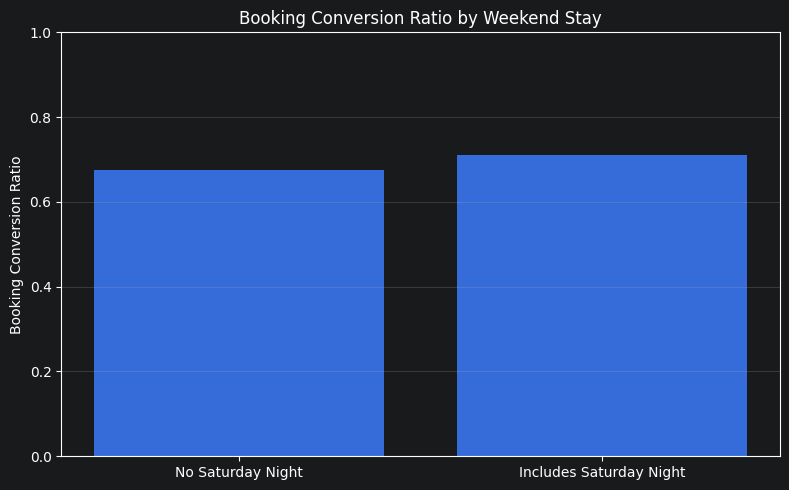

In [49]:
# Search-level dataframe
weekend_df = df.groupby("srch_id", observed=True).agg({
    "srch_saturday_night_bool": "mean",
    "booking_bool": "mean"
})

# Convert booking_bool into:
# did this search end with a booking?
weekend_df["booking_bool"] = (
    weekend_df["booking_bool"] != 0
).astype(int)

# Weekend vs non-weekend booking conversion ratio
weekend_ratio = (
    weekend_df
    .groupby("srch_saturday_night_bool")["booking_bool"]
    .mean()
)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Saturday Night", "Includes Saturday Night"],
    weekend_ratio.values
)

plt.ylabel("Booking Conversion Ratio")
plt.title("Booking Conversion Ratio by Weekend Stay")

plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3.8 Position Stats

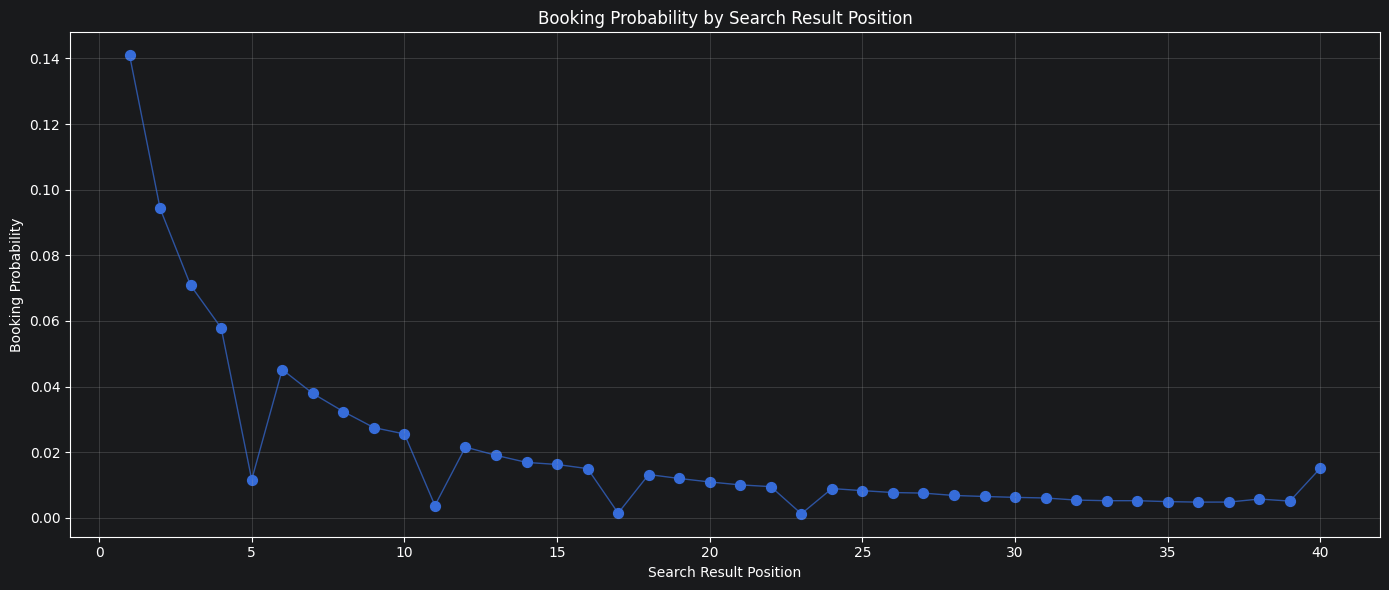

In [50]:
# ------------------------------------------
# Booking Probability by Position
# Scatter + Thin Line
# ------------------------------------------

position_booking_prob = (
    df.groupby("position")["booking_bool"]
      .mean()
)

plt.figure(figsize=(14, 6))

# Thin line
plt.plot(
    position_booking_prob.index,
    position_booking_prob.values,
    linewidth=1,
    alpha=0.7
)

# Scatter points
plt.scatter(
    position_booking_prob.index,
    position_booking_prob.values,
    s=50
)

plt.xlabel("Search Result Position")
plt.ylabel("Booking Probability")

plt.title("Booking Probability by Search Result Position")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

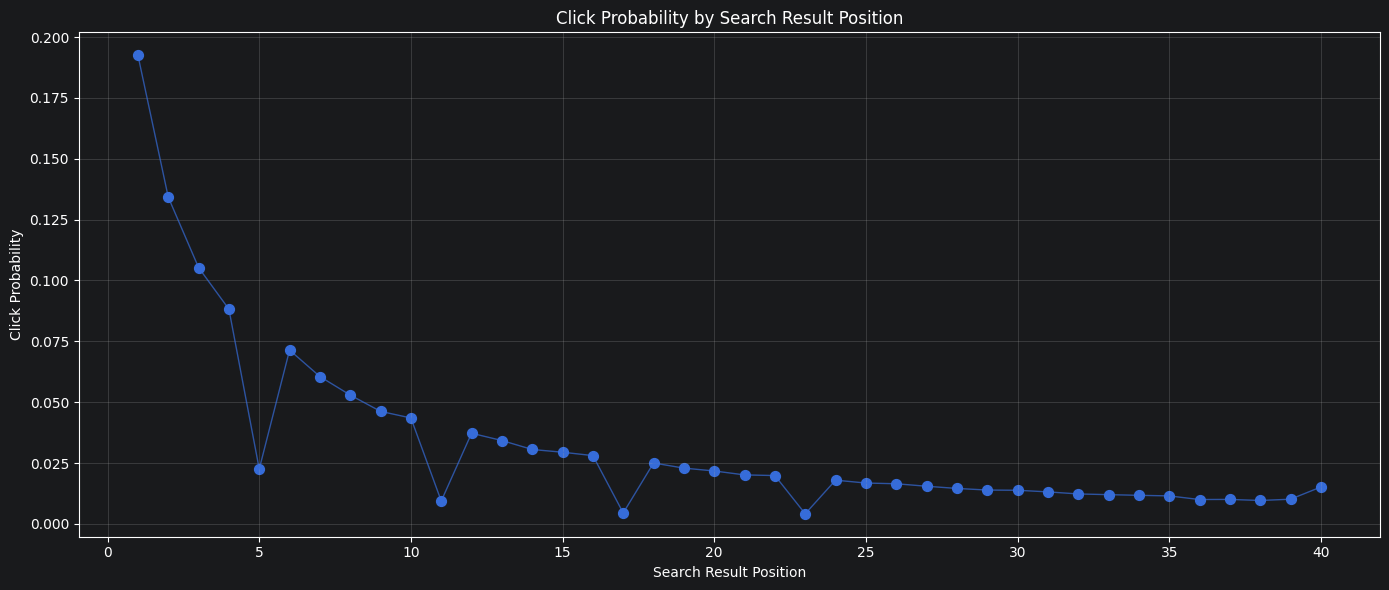

In [51]:
# ------------------------------------------
# Click Probability by Position
# Scatter + Thin Line
# ------------------------------------------

position_click_prob = (
    df.groupby("position")["click_bool"]
      .mean()
)

plt.figure(figsize=(14, 6))

# Thin line
plt.plot(
    position_click_prob.index,
    position_click_prob.values,
    linewidth=1,
    alpha=0.7
)

# Scatter points
plt.scatter(
    position_click_prob.index,
    position_click_prob.values,
    s=50
)

plt.xlabel("Search Result Position")
plt.ylabel("Click Probability")

plt.title("Click Probability by Search Result Position")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3.9 Promotion Flag and Brand Bool

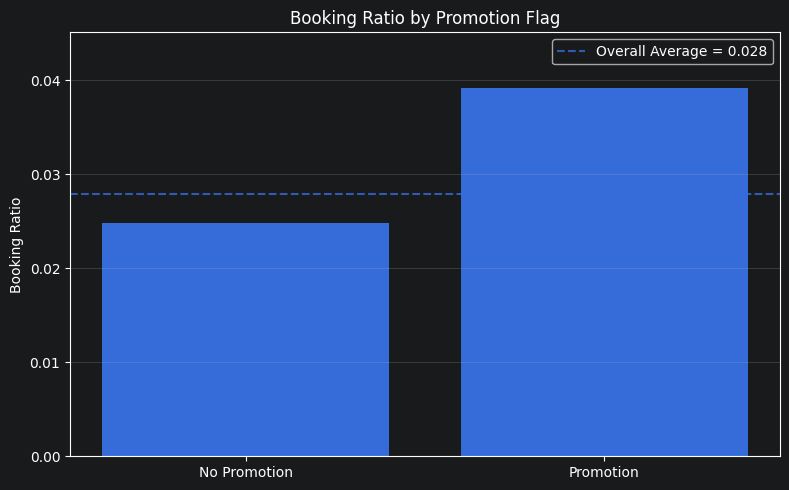

In [52]:
# ------------------------------------------
# Booking Ratio by Promotion Flag
# ------------------------------------------

promotion_booking_ratio = (
    df.groupby("promotion_flag")["booking_bool"]
      .mean()
)

overall_booking_ratio = df["booking_bool"].mean()

# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promotion_booking_ratio.values
)

# Overall average line
plt.axhline(
    y=overall_booking_ratio,
    linestyle="--",
    alpha=0.8,
    label=f"Overall Average = {overall_booking_ratio:.3f}"
)

plt.ylabel("Booking Ratio")
plt.title("Booking Ratio by Promotion Flag")

plt.ylim(0, promotion_booking_ratio.max() * 1.15)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

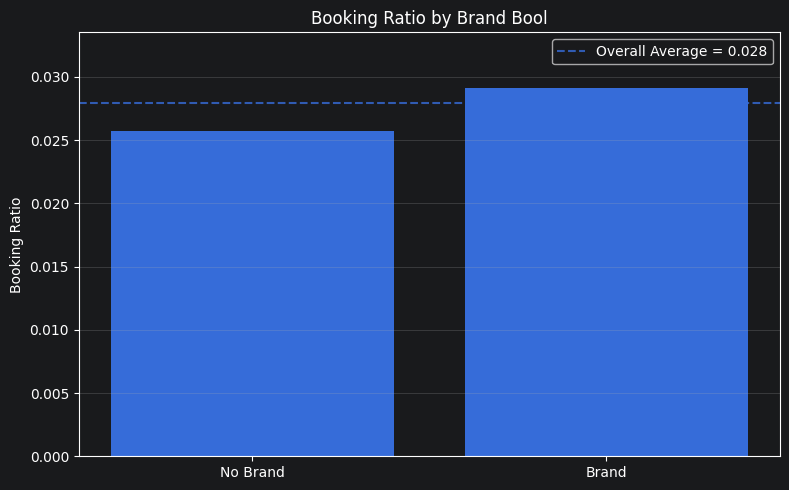

In [53]:
# ------------------------------------------
# Booking Ratio by Promotion Flag
# ------------------------------------------

brand_ratio = (
    df.groupby("prop_brand_bool")["booking_bool"]
      .mean()
)

overall_booking_ratio = df["booking_bool"].mean()

# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["No Brand", "Brand"],
    brand_ratio.values
)

# Overall average line
plt.axhline(
    y=overall_booking_ratio,
    linestyle="--",
    alpha=0.8,
    label=f"Overall Average = {overall_booking_ratio:.3f}"
)

plt.ylabel("Booking Ratio")
plt.title("Booking Ratio by Brand Bool")

plt.ylim(0, brand_ratio.max() * 1.15)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

## 3.10 Correlations

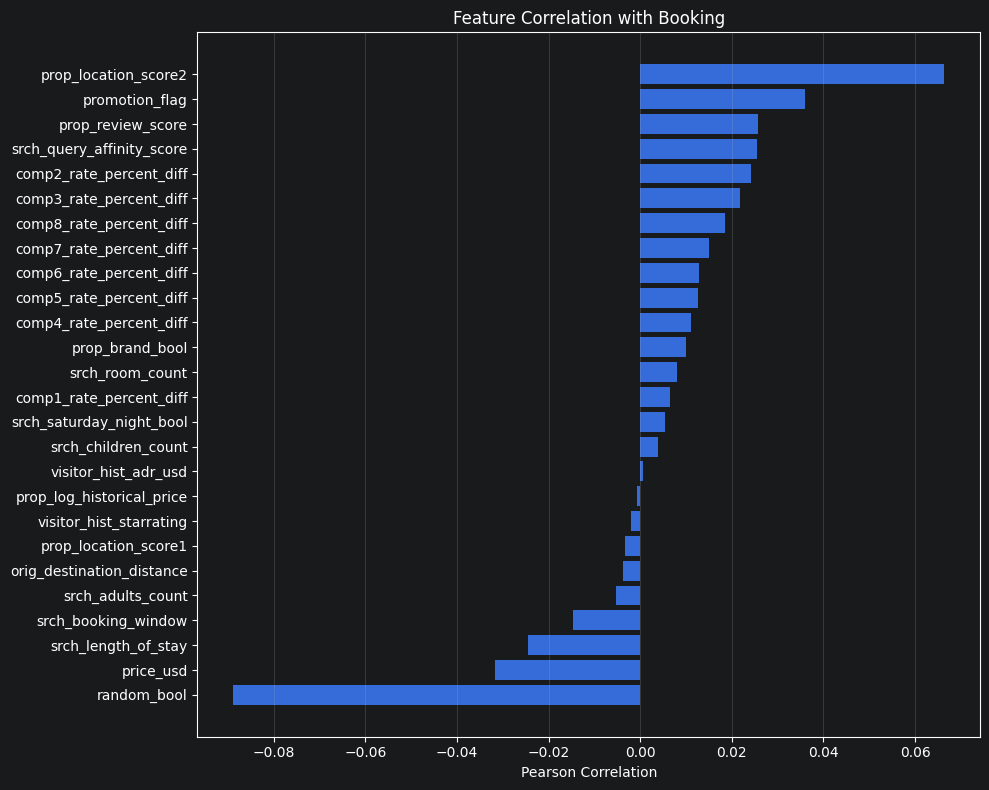

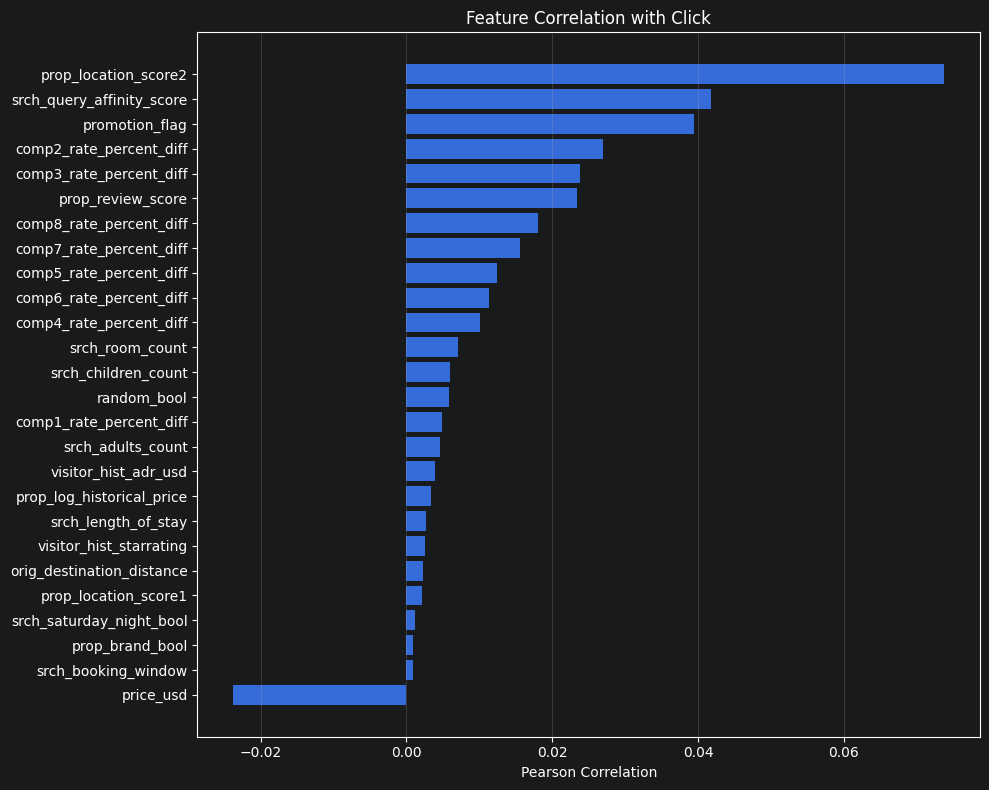

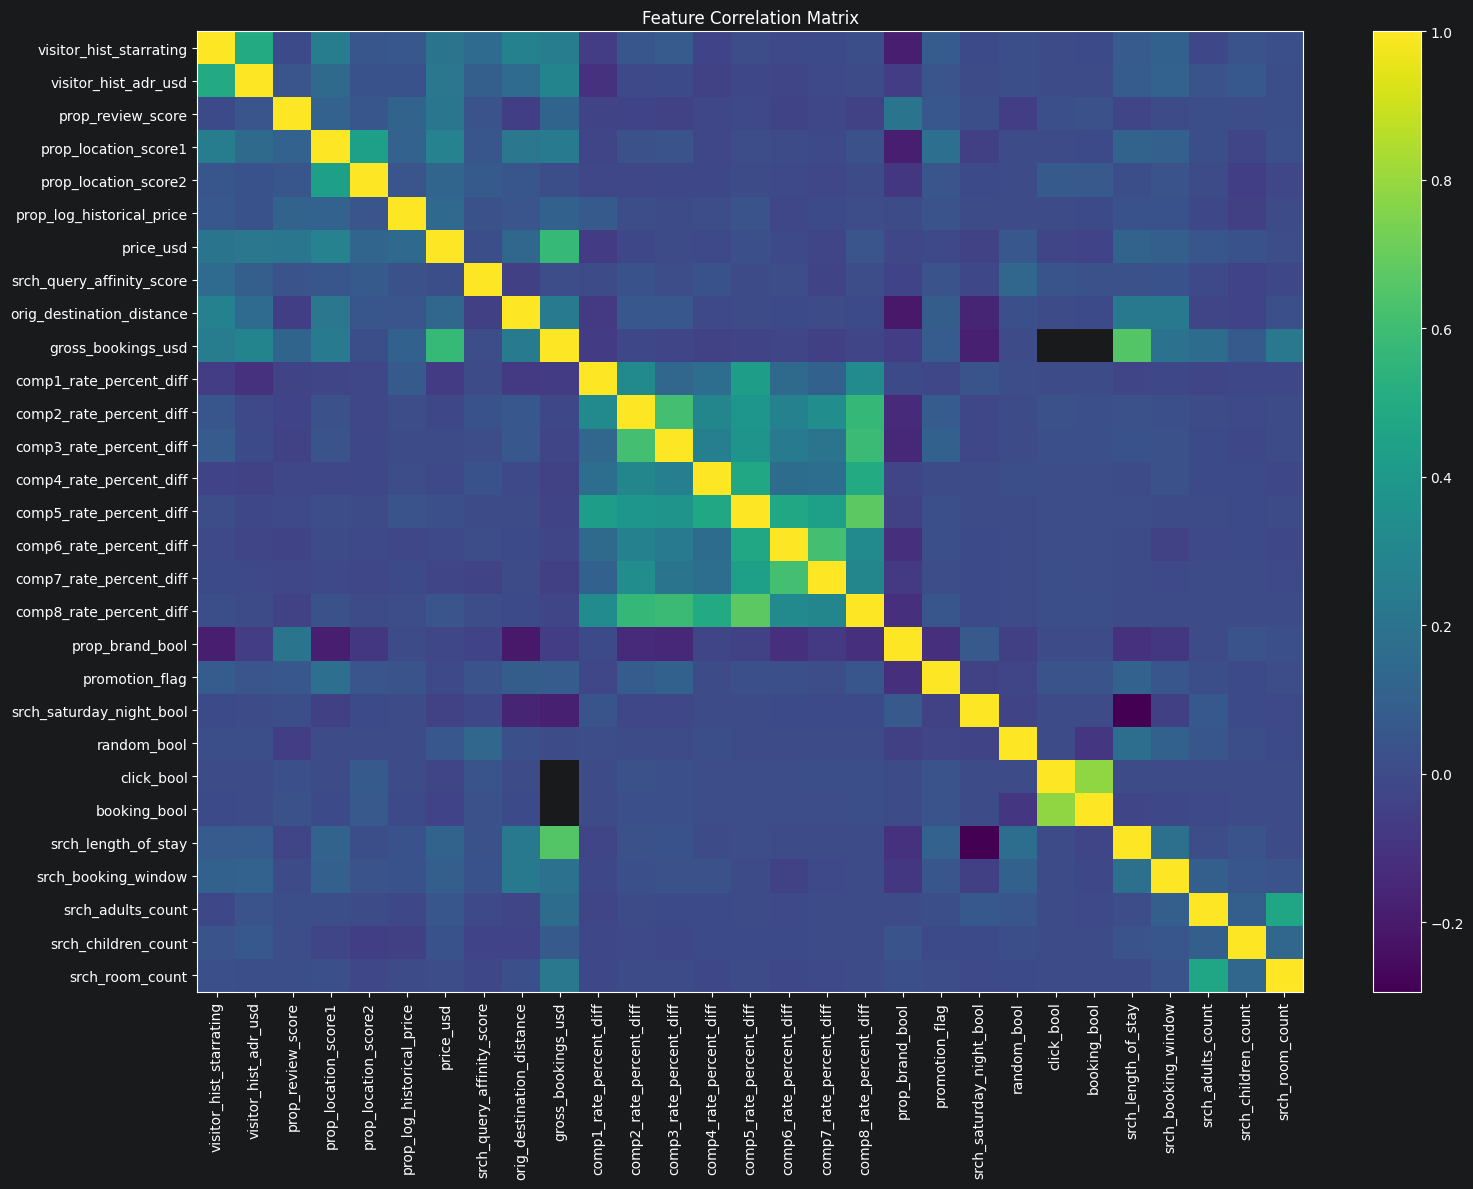

In [54]:
# ==========================================
# Correlation Analysis
# ==========================================

# ------------------------------------------
# Columns to include
# ------------------------------------------

corr_cols = (
    cont_cols +
    bool_cols +
    int_cols
)

# Remove unwanted columns
corr_cols = [
    c for c in corr_cols
    if c not in ["position"]
]

# Create numeric dataframe
corr_df = df[corr_cols].copy()

# Convert booleans to integers
for col in bool_cols:
    corr_df[col] = corr_df[col].astype("int8")


# ==========================================
# 1. Correlation with booking_bool
# Exclude click_bool
# ==========================================

booking_corr_df = corr_df.drop(columns=["click_bool", "gross_bookings_usd"])

booking_corr = (
    booking_corr_df
    .corr(numeric_only=True)["booking_bool"]
    .drop("booking_bool")
    .sort_values()
)

plt.figure(figsize=(10, 8))

plt.barh(
    booking_corr.index,
    booking_corr.values
)

plt.title("Feature Correlation with Booking")
plt.xlabel("Pearson Correlation")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# 2. Correlation with click_bool
# Exclude booking_bool
# ==========================================

click_corr_df = corr_df.drop(columns=["booking_bool", "gross_bookings_usd"])

click_corr = (
    click_corr_df
    .corr(numeric_only=True)["click_bool"]
    .drop("click_bool")
    .sort_values()
)

plt.figure(figsize=(10, 8))

plt.barh(
    click_corr.index,
    click_corr.values
)

plt.title("Feature Correlation with Click")
plt.xlabel("Pearson Correlation")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# 3. Full Correlation Heatmap
# ==========================================

full_corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

plt.imshow(full_corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(full_corr.columns)),
    full_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(full_corr.columns)),
    full_corr.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## 3.11 - Groupby Property Id Stats

C:\Users\gerib\AppData\Local\Temp\ipykernel_32124\3318424433.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("prop_id")["booking_bool"]


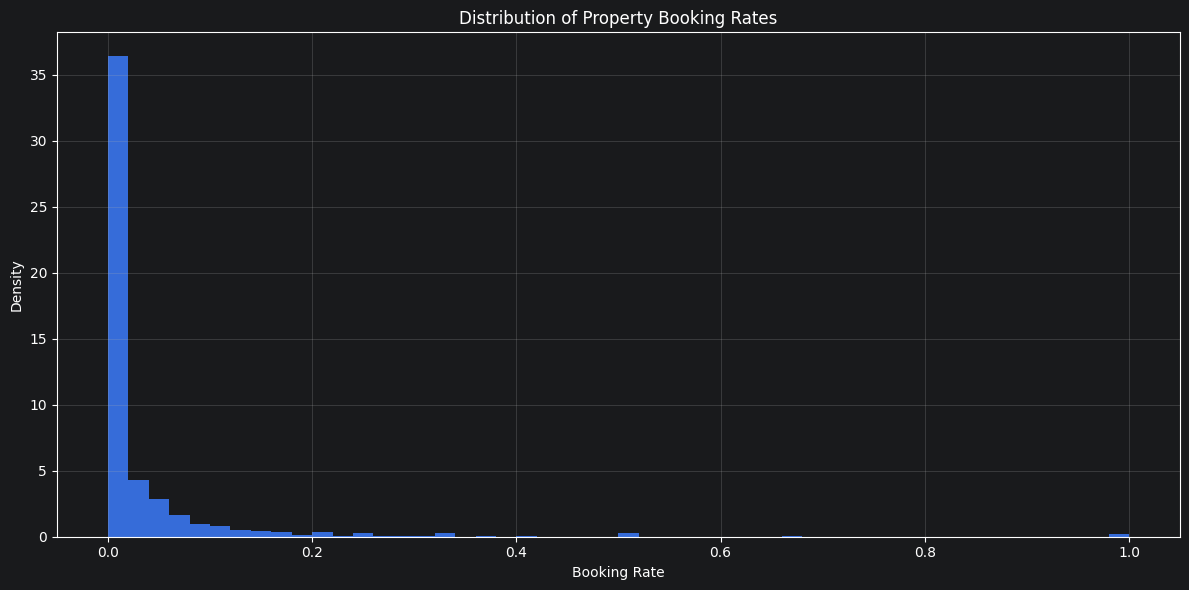

In [55]:
# ==========================================
# 1. Booking Rate by Property
# ==========================================

prop_booking_rate = (
    df.groupby("prop_id")["booking_bool"]
      .mean()
)

plt.figure(figsize=(12, 6))

plt.hist(
    prop_booking_rate,
    bins=50,
    density=True
)

plt.title("Distribution of Property Booking Rates")
plt.xlabel("Booking Rate")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

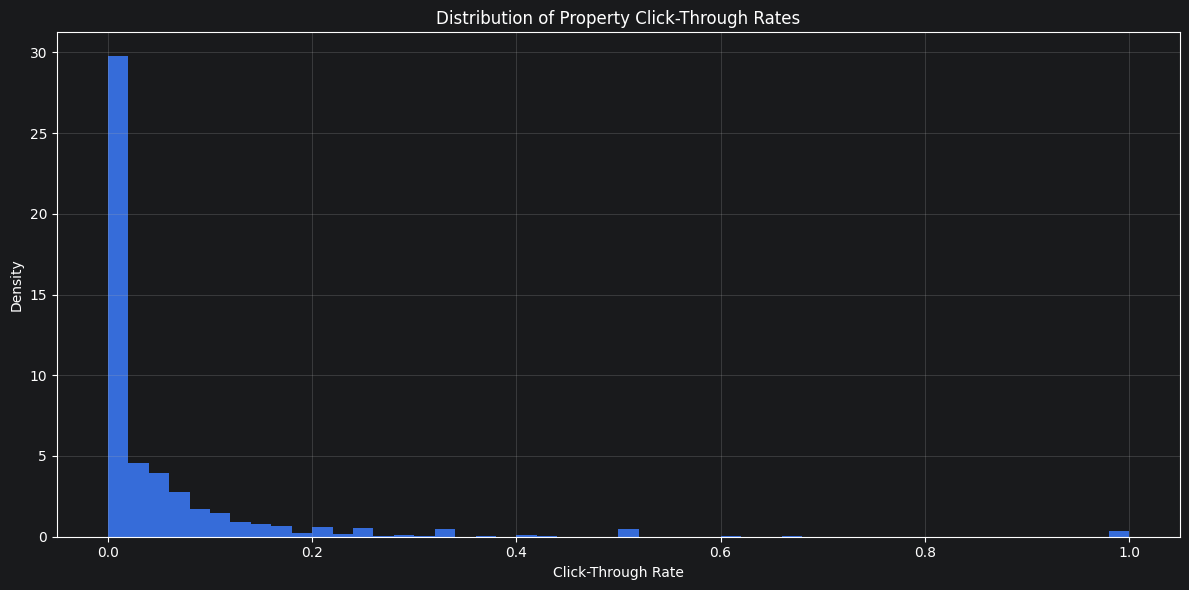

In [56]:
# ==========================================
# 2. Click-Through Rate by Property
# ==========================================

prop_click_rate = (
    df.groupby("prop_id", observed = True)["click_bool"]
      .mean()
)

plt.figure(figsize=(12, 6))

plt.hist(
    prop_click_rate,
    bins=50,
    density=True
)

plt.title("Distribution of Property Click-Through Rates")
plt.xlabel("Click-Through Rate")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

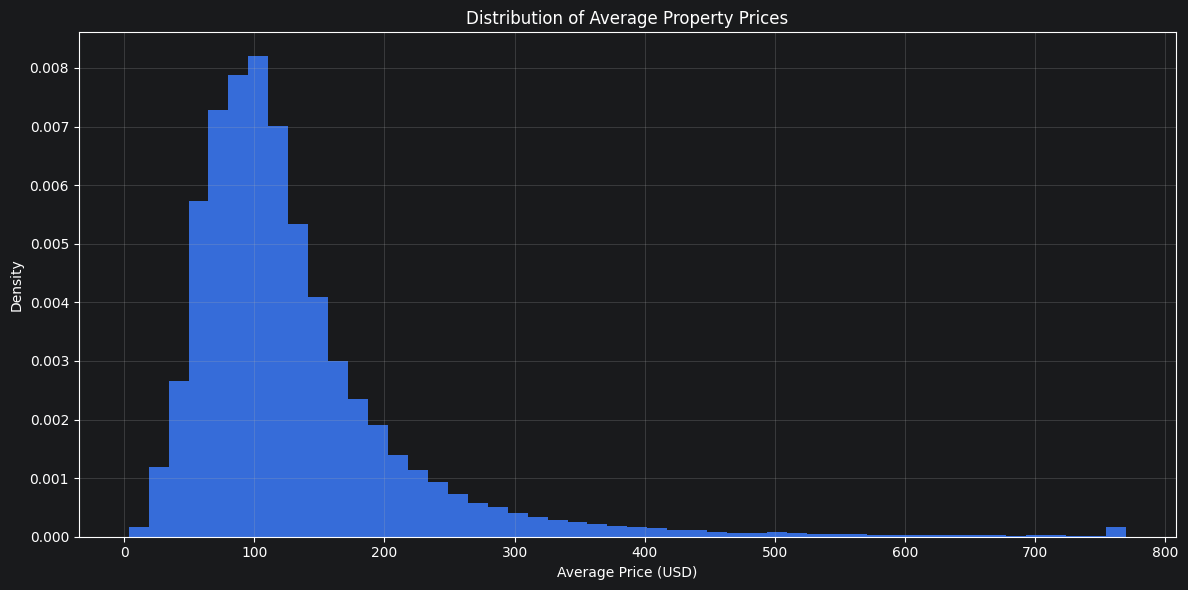

In [57]:
# ==========================================
# 3. Average Price by Property
# ==========================================

prop_avg_price = (
    df.groupby("prop_id", observed = True)["price_usd"]
      .mean()
)

plt.figure(figsize=(12, 6))

plt.hist(
    prop_avg_price,
    bins=50,
    density=True
)

plt.title("Distribution of Average Property Prices")
plt.xlabel("Average Price (USD)")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

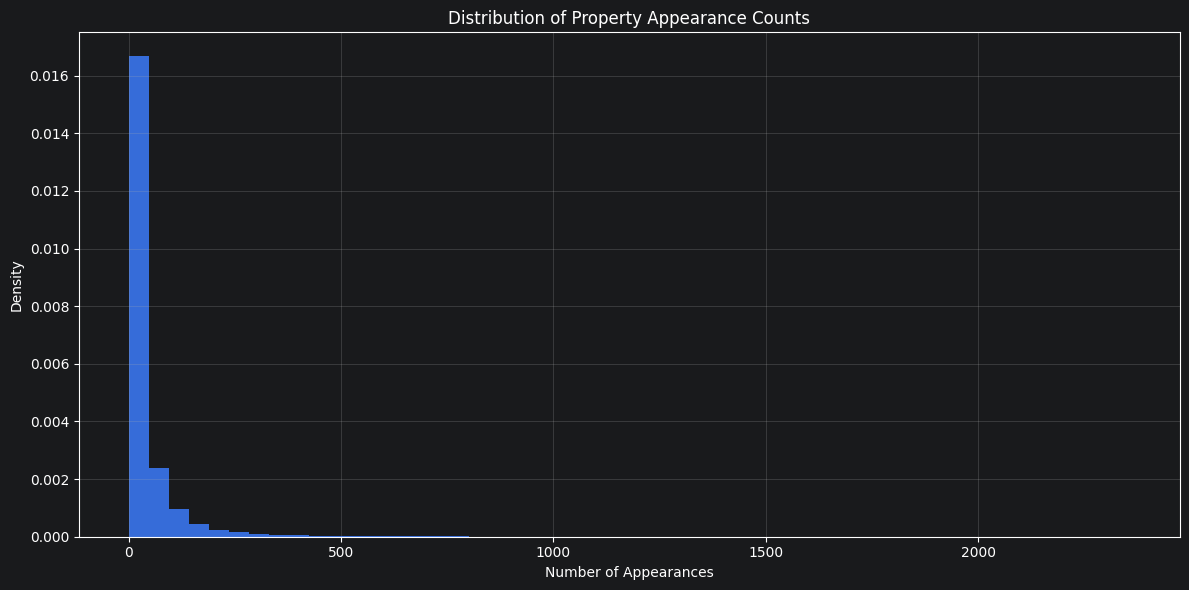

In [58]:
# ==========================================
# 4. Number of Appearances per Property
# ==========================================

prop_appearances = (
    df.groupby("prop_id", observed = True)
      .size()
)

plt.figure(figsize=(12, 6))

plt.hist(
    prop_appearances,
    bins=50,
    density=True
)

plt.title("Distribution of Property Appearance Counts")
plt.xlabel("Number of Appearances")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()